# Basic Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

%matplotlib inline
sns.set(style='whitegrid', palette='muted', font_scale=1.1)

In [3]:
# Load the combined prices
df_prices = pd.read_csv('prices_combined.csv', sep=';')

# Load the combined trades
df_trades = pd.read_csv('trades_combined.csv', sep=';')

# Display the first few rows to verify
display(df_prices.head())
display(df_trades.head())


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,25,NaN,NaN,NaN,NaN,23.0,0.0
1,0,0,VEV_6000,0,25,NaN,NaN,NaN,NaN,1,25,NaN,NaN,NaN,NaN,0.5,0.0
2,0,0,VEV_5100,169,19,NaN,NaN,NaN,NaN,174,19,NaN,NaN,NaN,NaN,171.5,0.0
3,0,0,VEV_4000,1240,7,1237.0,24.0,NaN,NaN,1260,7,1263.0,24.0,NaN,NaN,1250.0,0.0
4,0,0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,15,10010.0,30.0,NaN,NaN,10000.0,0.0


,timestamp,buyer,seller,symbol,currency,price,quantity,day
0,2500,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5250.0,4,0
1,2900,NaN,NaN,VEV_5400,XIRECS,22.0,3,0
2,2900,NaN,NaN,VEV_5500,XIRECS,8.0,3,0
3,2900,NaN,NaN,VEV_6000,XIRECS,0.0,3,0
4,2900,NaN,NaN,VEV_6500,XIRECS,0.0,3,0


In [4]:
# Filter prices (column is 'product')
df_prices = df_prices[df_prices['product'] == 'HYDROGEL_PACK'].copy().sort_values('timestamp')

# Filter trades (column is 'symbol')
df_trades = df_trades[df_trades['symbol'] == 'HYDROGEL_PACK'].copy().sort_values('timestamp')

# Verify the filter
display(df_prices.head())
display(df_trades.head())


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
4,0,0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,15,10010.0,30.0,NaN,NaN,10000.0,0.0
12,0,100,HYDROGEL_PACK,9992,13,9990.0,30.0,NaN,NaN,10008,13,10011.0,30.0,NaN,NaN,10000.0,0.0
34,0,200,HYDROGEL_PACK,9995,13,9992.0,21.0,NaN,NaN,10011,13,10013.0,21.0,NaN,NaN,10003.0,0.0
42,0,300,HYDROGEL_PACK,9994,11,9992.0,23.0,NaN,NaN,10010,11,10013.0,23.0,NaN,NaN,10002.0,0.0
52,0,400,HYDROGEL_PACK,9995,13,9993.0,23.0,NaN,NaN,10011,13,10014.0,23.0,NaN,NaN,10003.0,0.0


,timestamp,buyer,seller,symbol,currency,price,quantity,day
7,8000,NaN,NaN,HYDROGEL_PACK,XIRECS,10018.0,6,0
10,10100,NaN,NaN,HYDROGEL_PACK,XIRECS,10014.0,5,0
18,15300,NaN,NaN,HYDROGEL_PACK,XIRECS,10026.0,3,0
20,15700,NaN,NaN,HYDROGEL_PACK,XIRECS,10009.0,2,0
21,16400,NaN,NaN,HYDROGEL_PACK,XIRECS,10009.0,4,0


In [5]:
# To get unique buyers
unique_buyers = df_trades['buyer'].unique()
unique_buyers_numbers = [int(buyer.split()[1]) for buyer in unique_buyers if pd.notna(buyer)]
print("Unique Buyers:", unique_buyers)

# To get unique sellers
unique_sellers = df_trades['seller'].unique()
unique_sellers_numbers = [int(seller.split()[1]) for seller in unique_sellers if pd.notna(seller)]
print("Unique Sellers:", unique_sellers)

# To get unique values from both combined
unique_participants = pd.unique(df_trades[['buyer', 'seller']].values.ravel('K'))
print("All Unique Participants:", unique_participants)


Unique Buyers: <StringArray>
[nan, 'Mark 38', 'Mark 14', 'Mark 22']
Length: 4, dtype: str
Unique Sellers: <StringArray>
[nan, 'Mark 22', 'Mark 14', 'Mark 38']
Length: 4, dtype: str
All Unique Participants: [nan 'Mark 38' 'Mark 14' 'Mark 22']


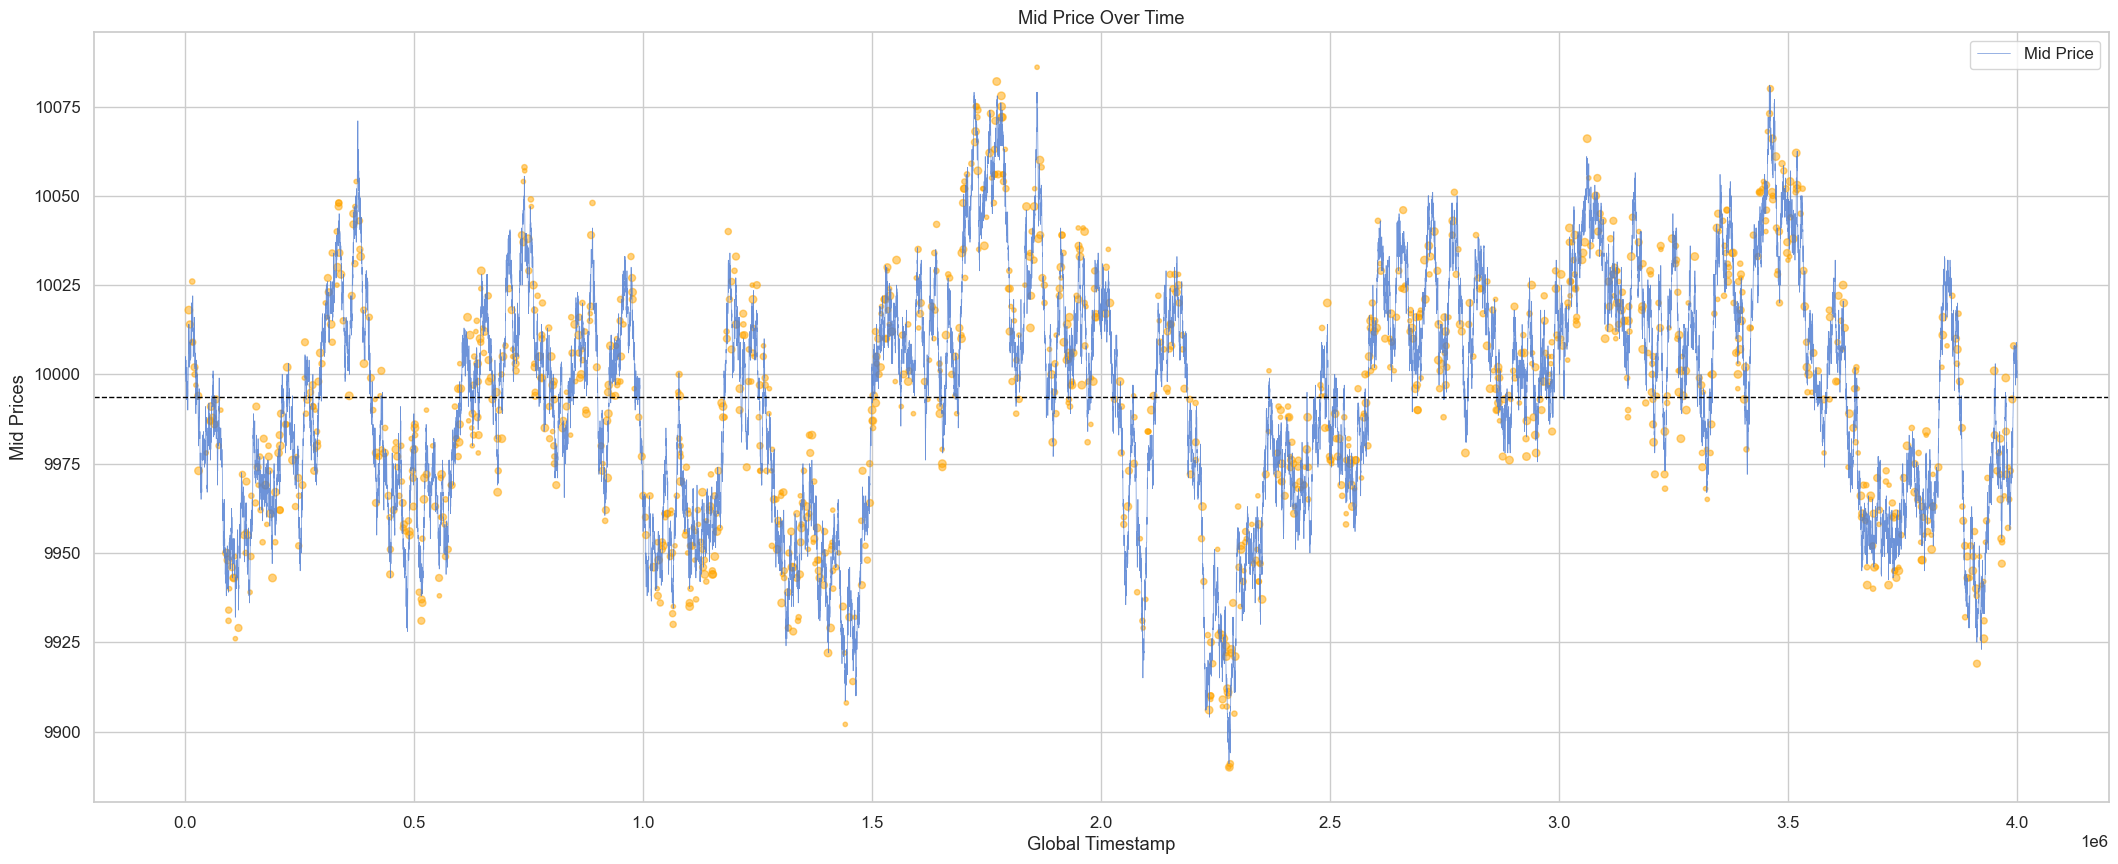

In [6]:
plt.figure(figsize=(26, 10))
plt.plot(df_prices['timestamp'], df_prices['mid_price'], label='Mid Price', alpha=0.8, linewidth=0.5)
plt.scatter(df_trades['timestamp'], df_trades['price'], s = df_trades['quantity']*5, alpha = 0.5, color = 'orange')
plt.axhline(df_prices['mid_price'].mean(), color='black', linestyle='--', linewidth = 1)
plt.title('Mid Price Over Time')
plt.xlabel('Global Timestamp')
plt.ylabel('Mid Prices')
plt.legend()
plt.show()

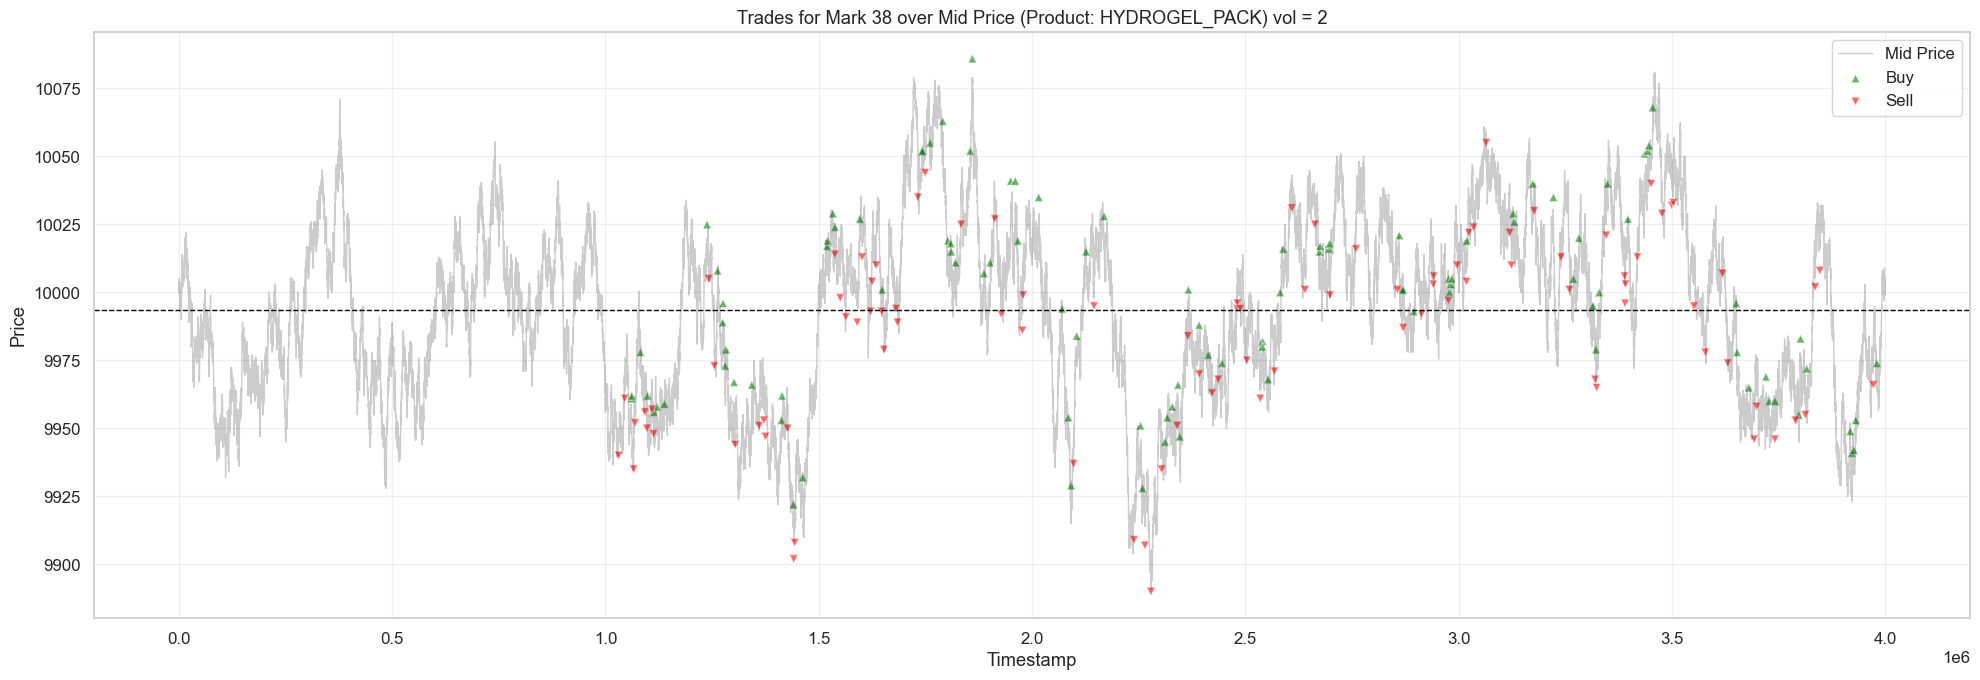

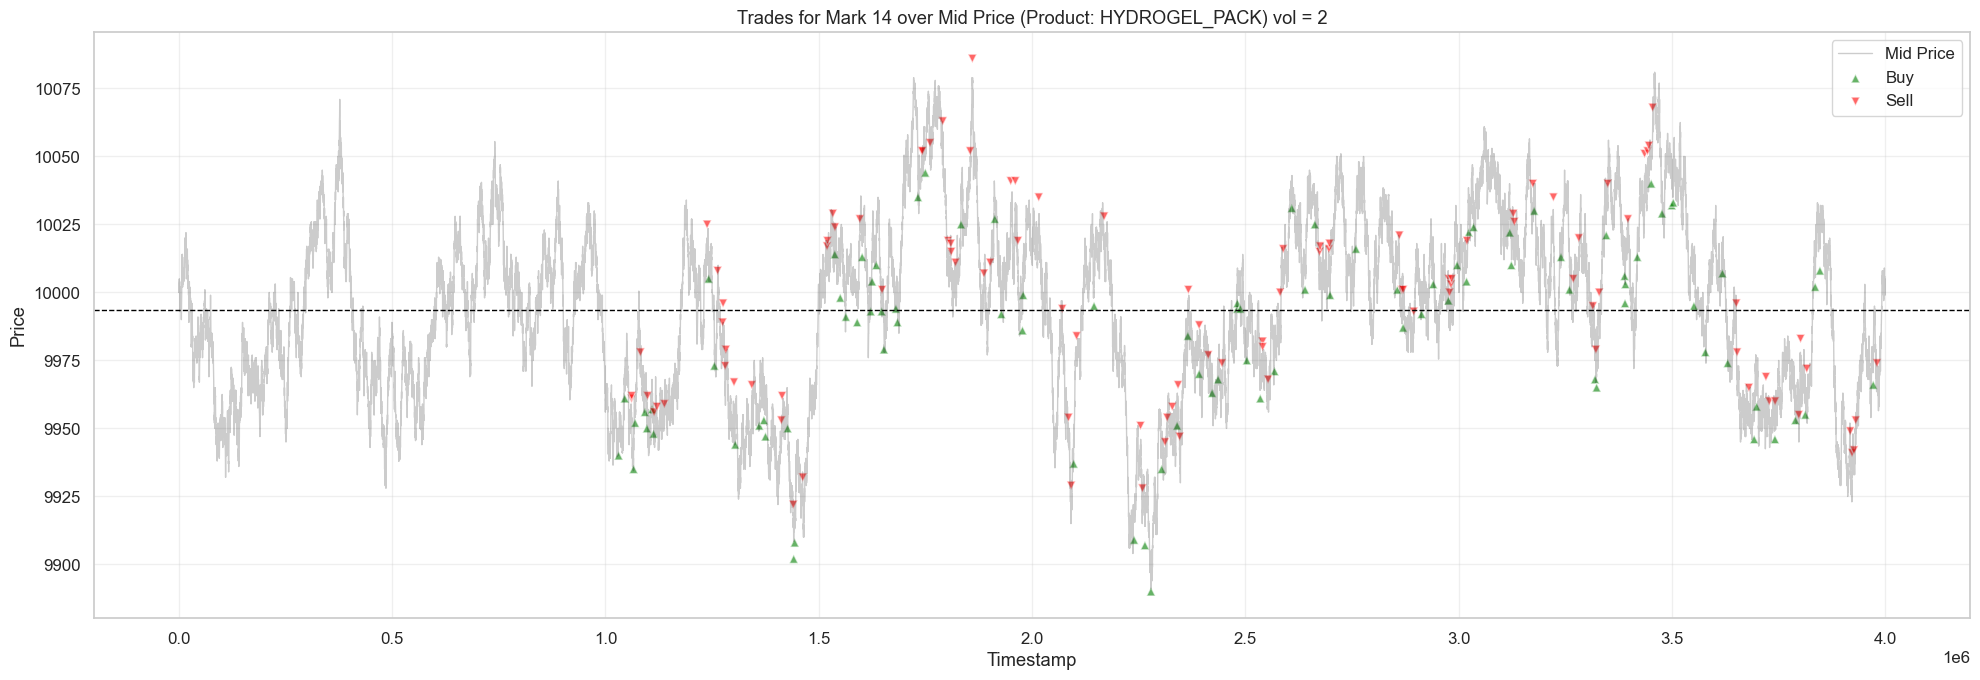

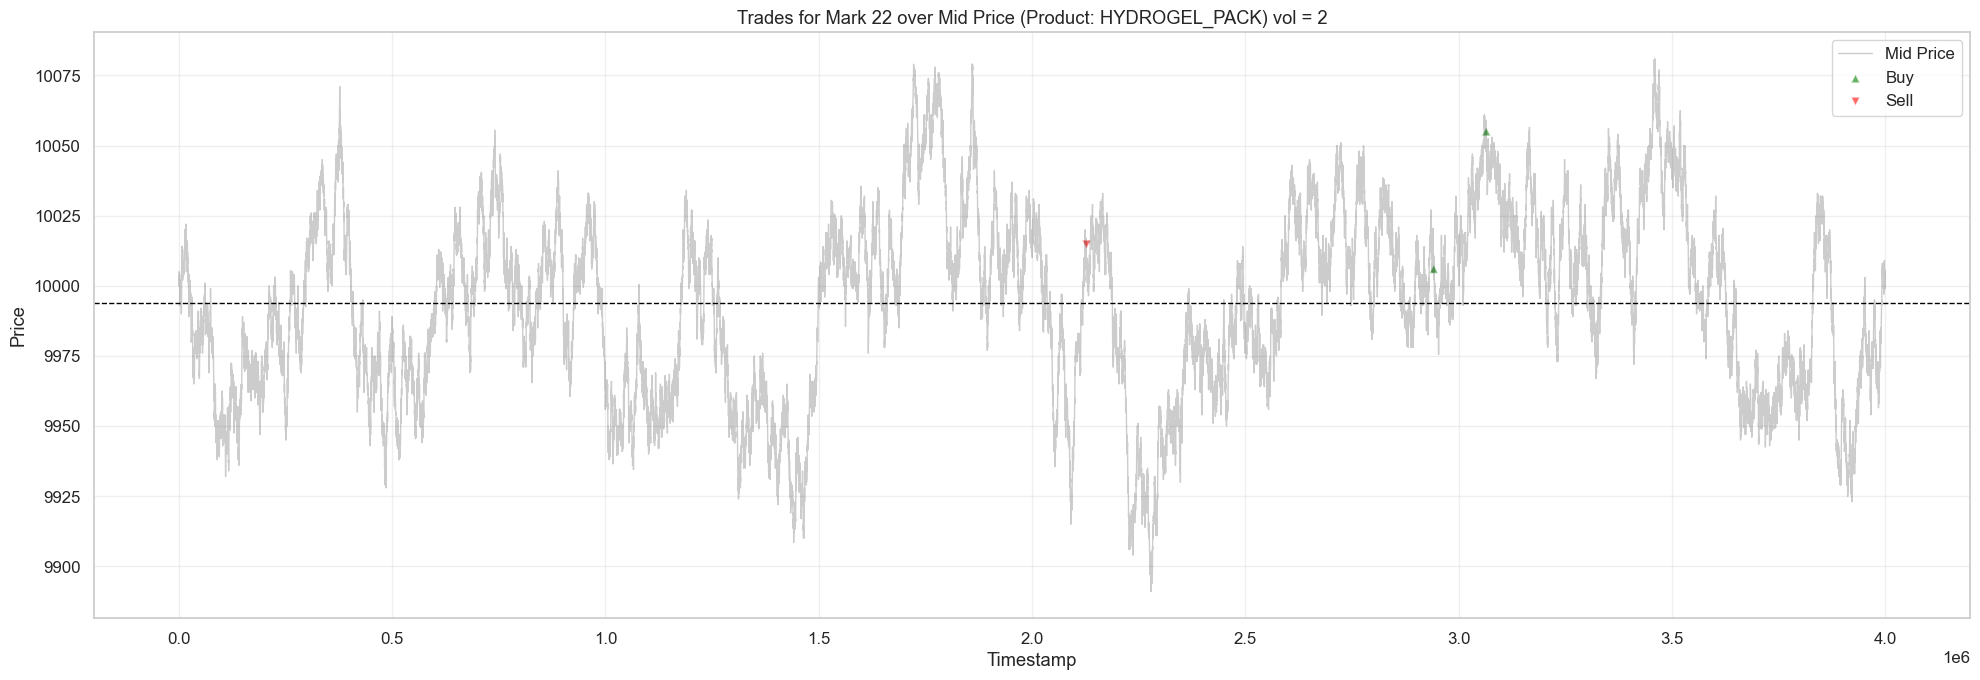

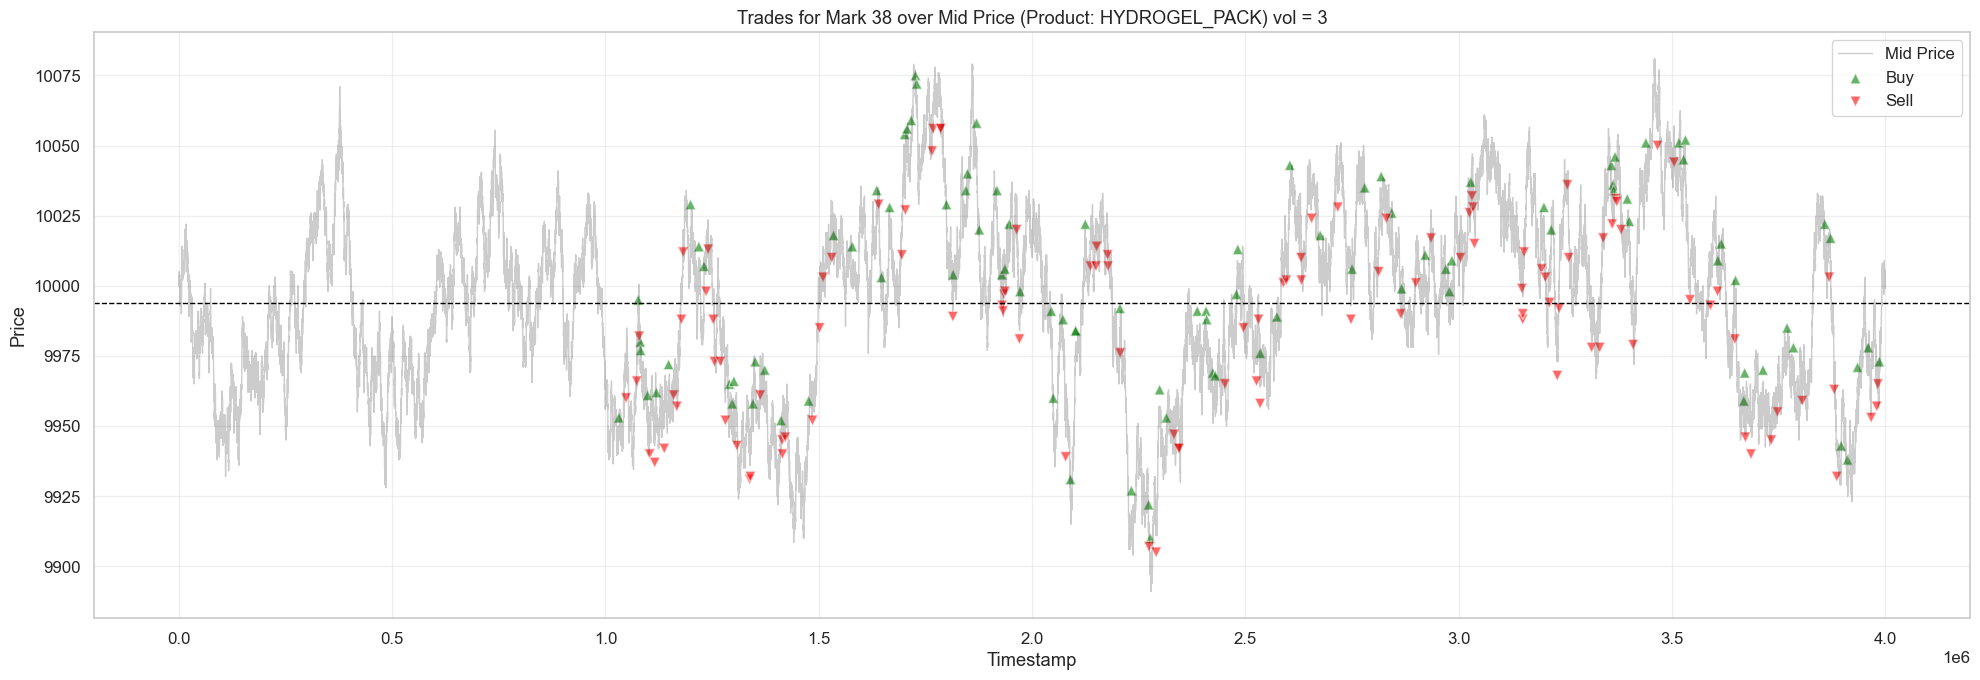

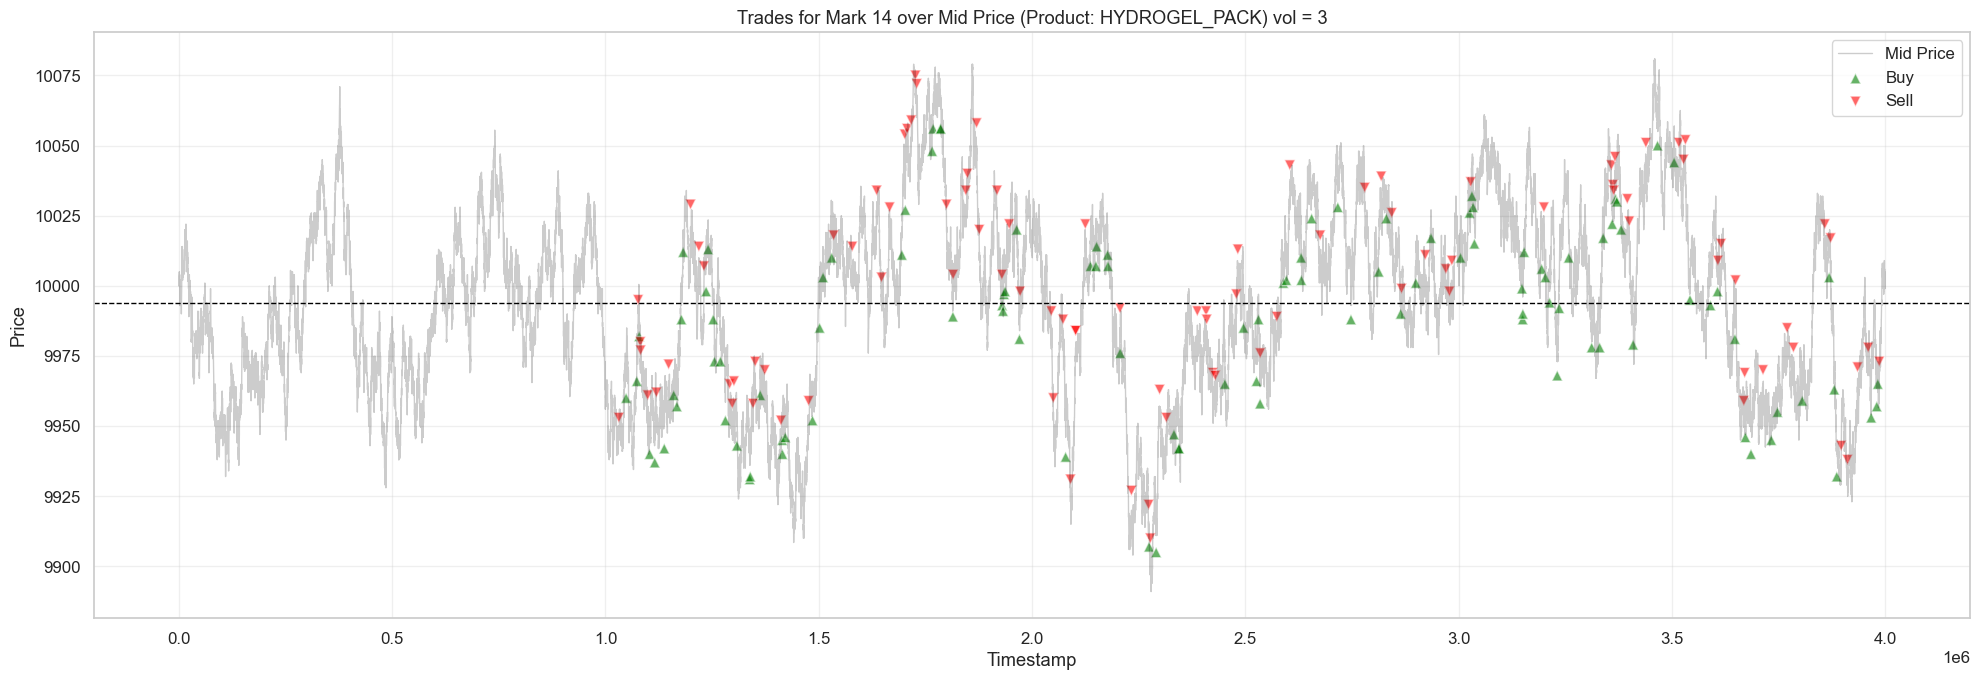

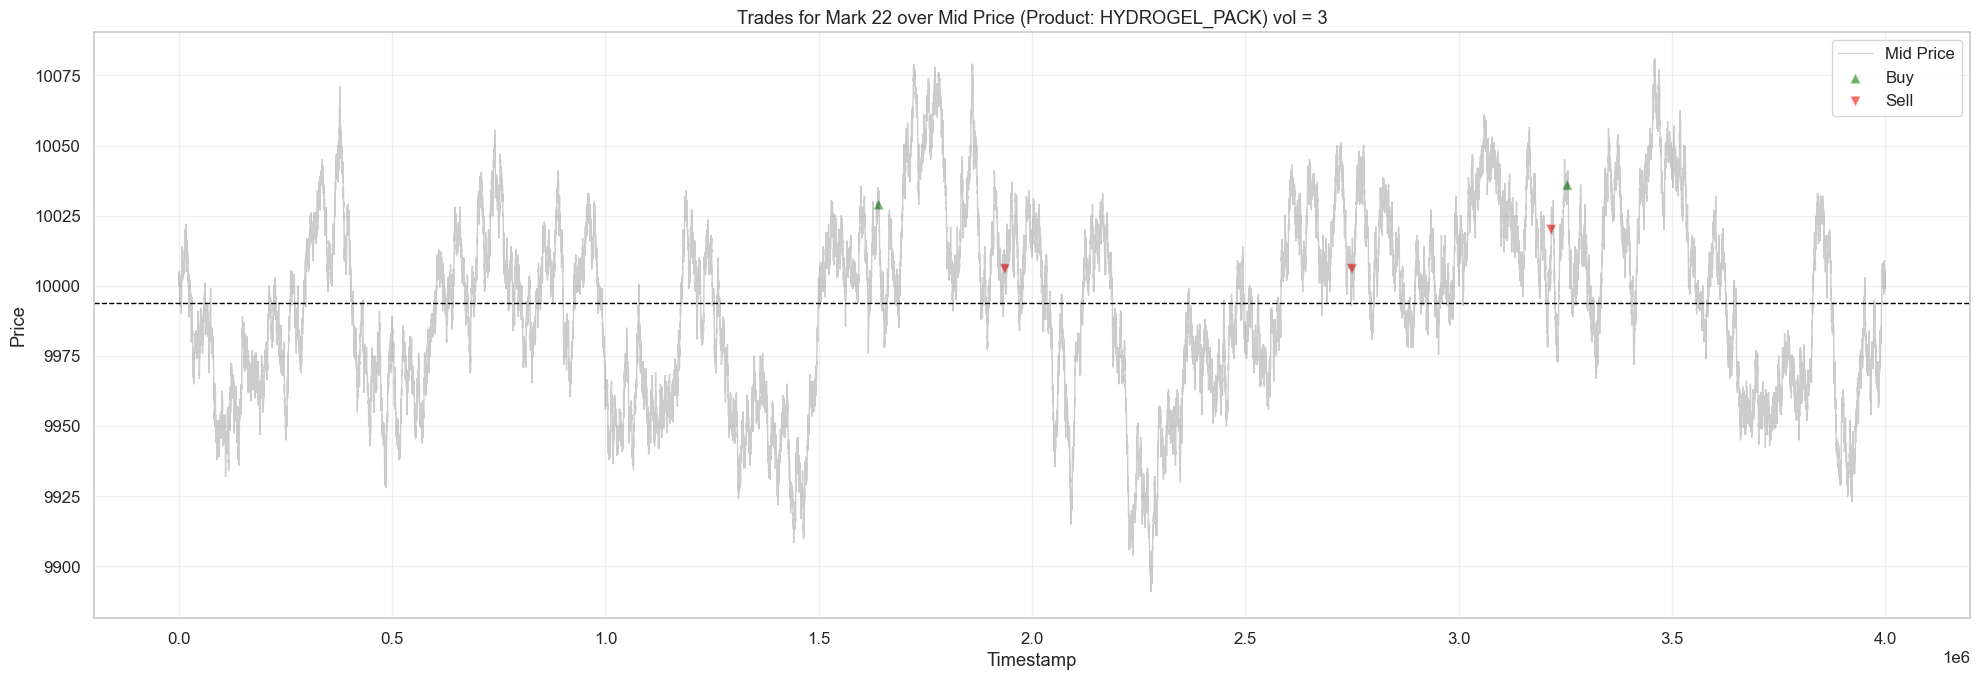

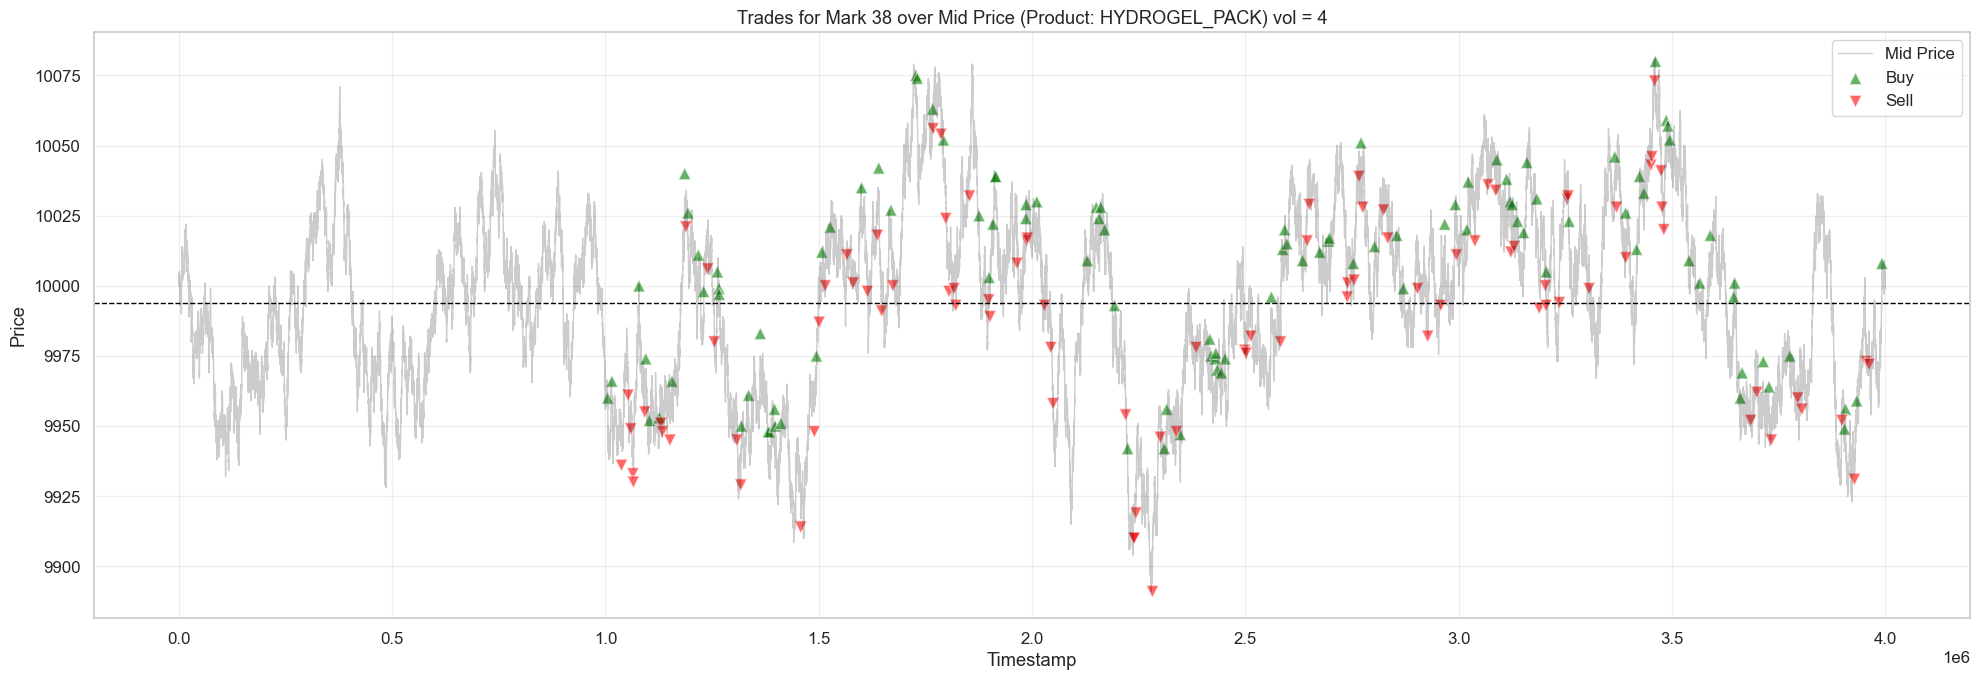

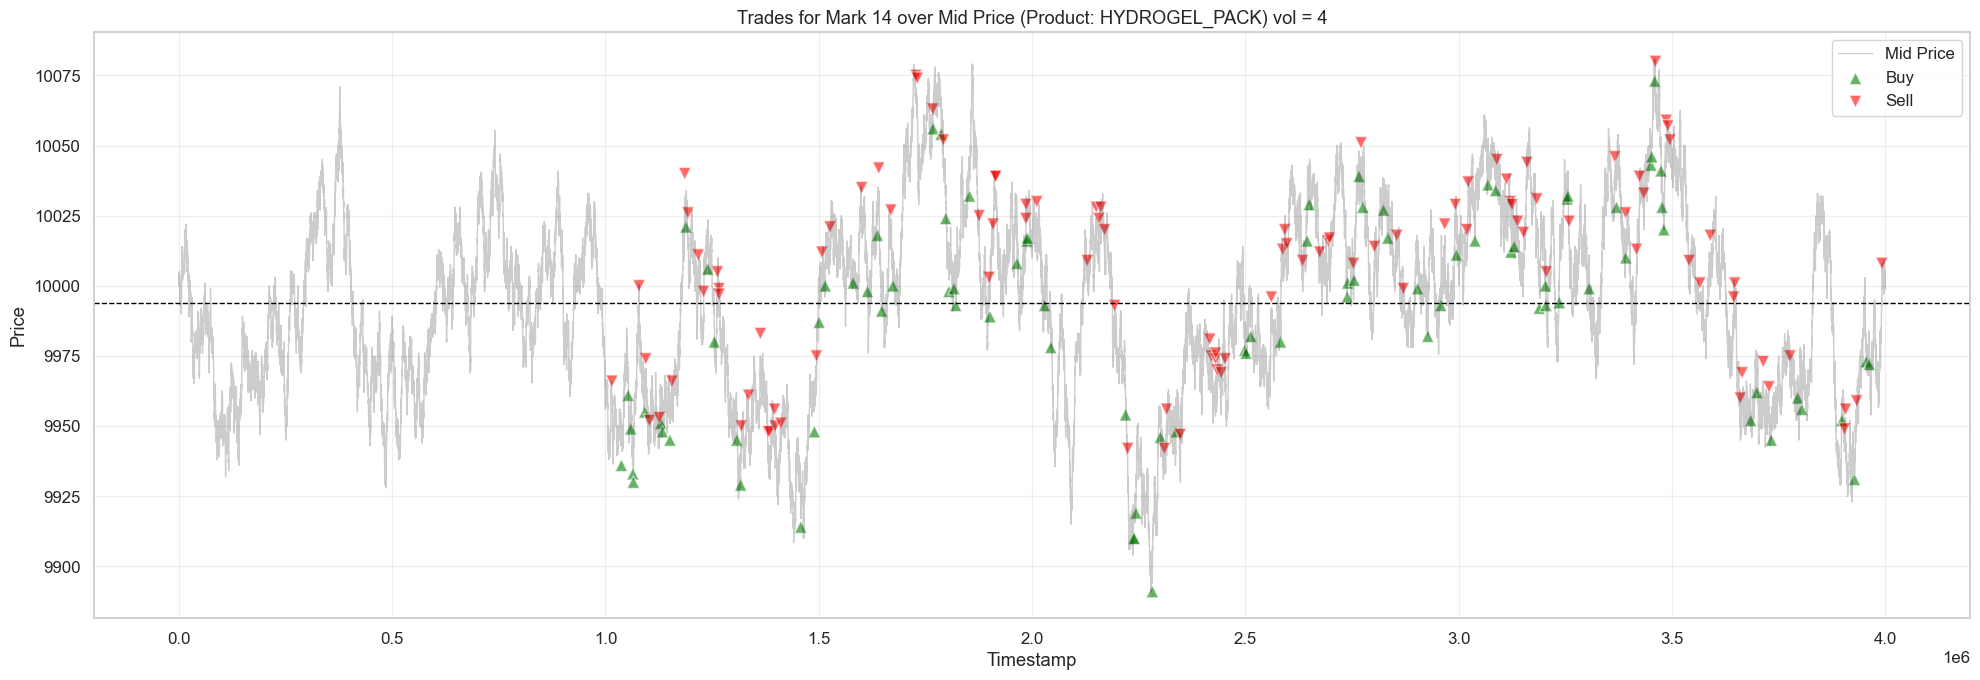

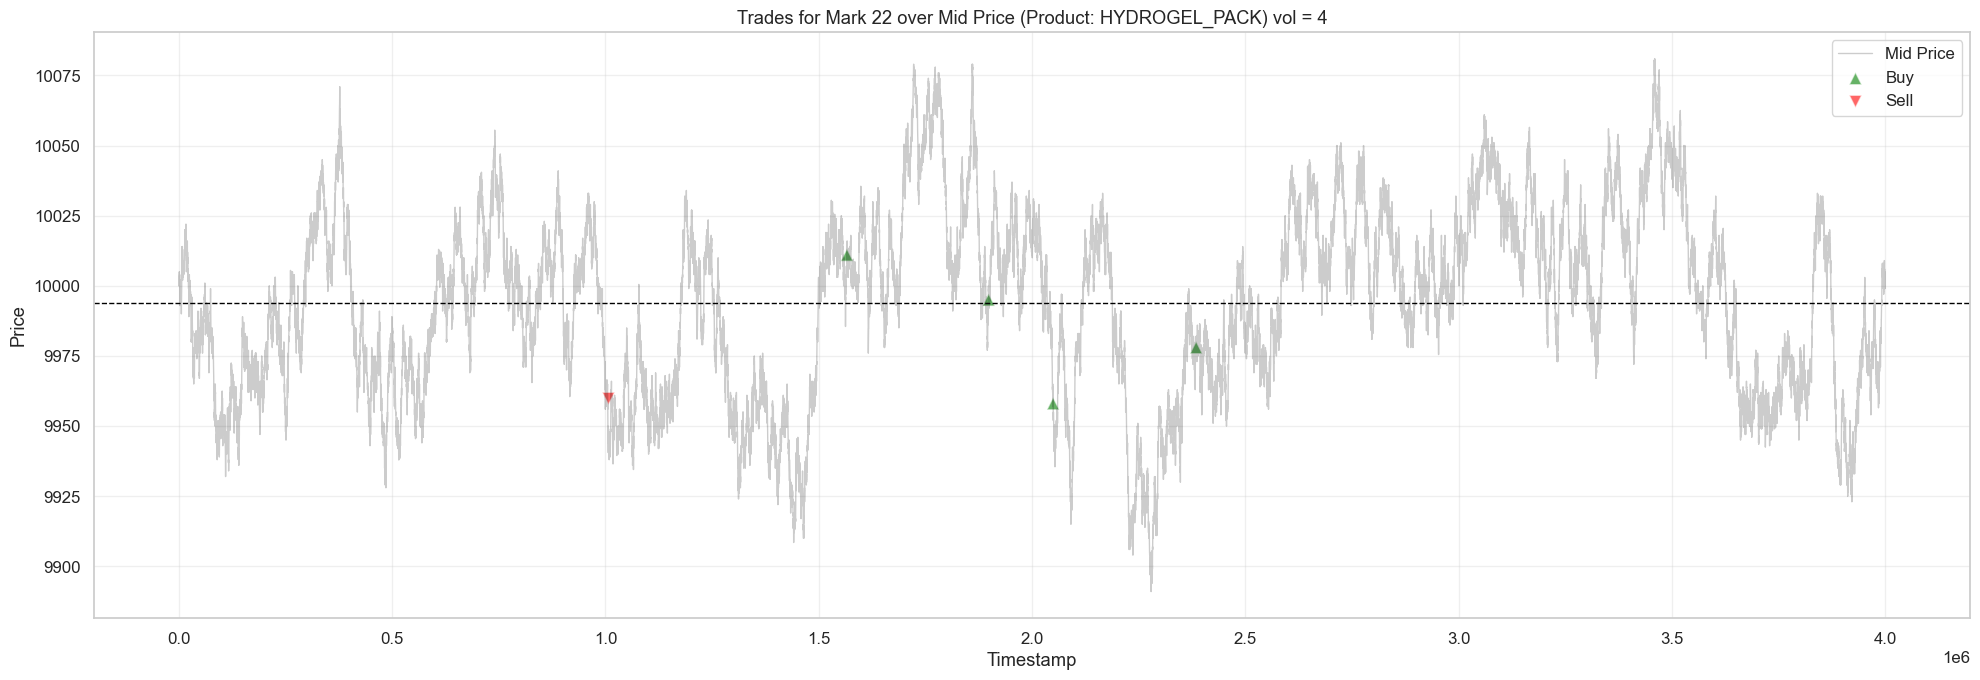

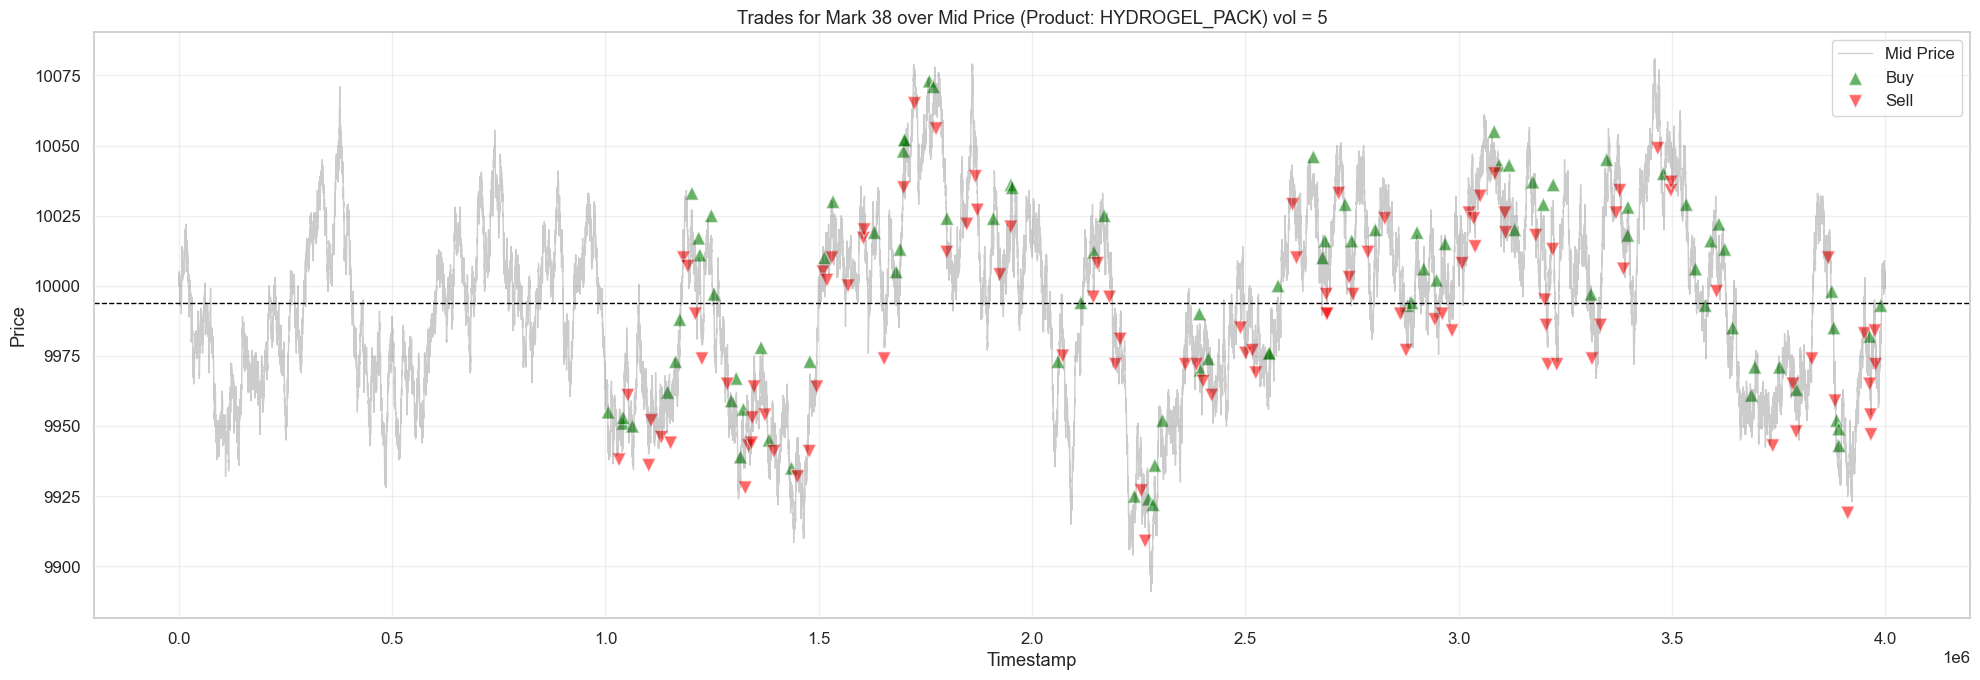

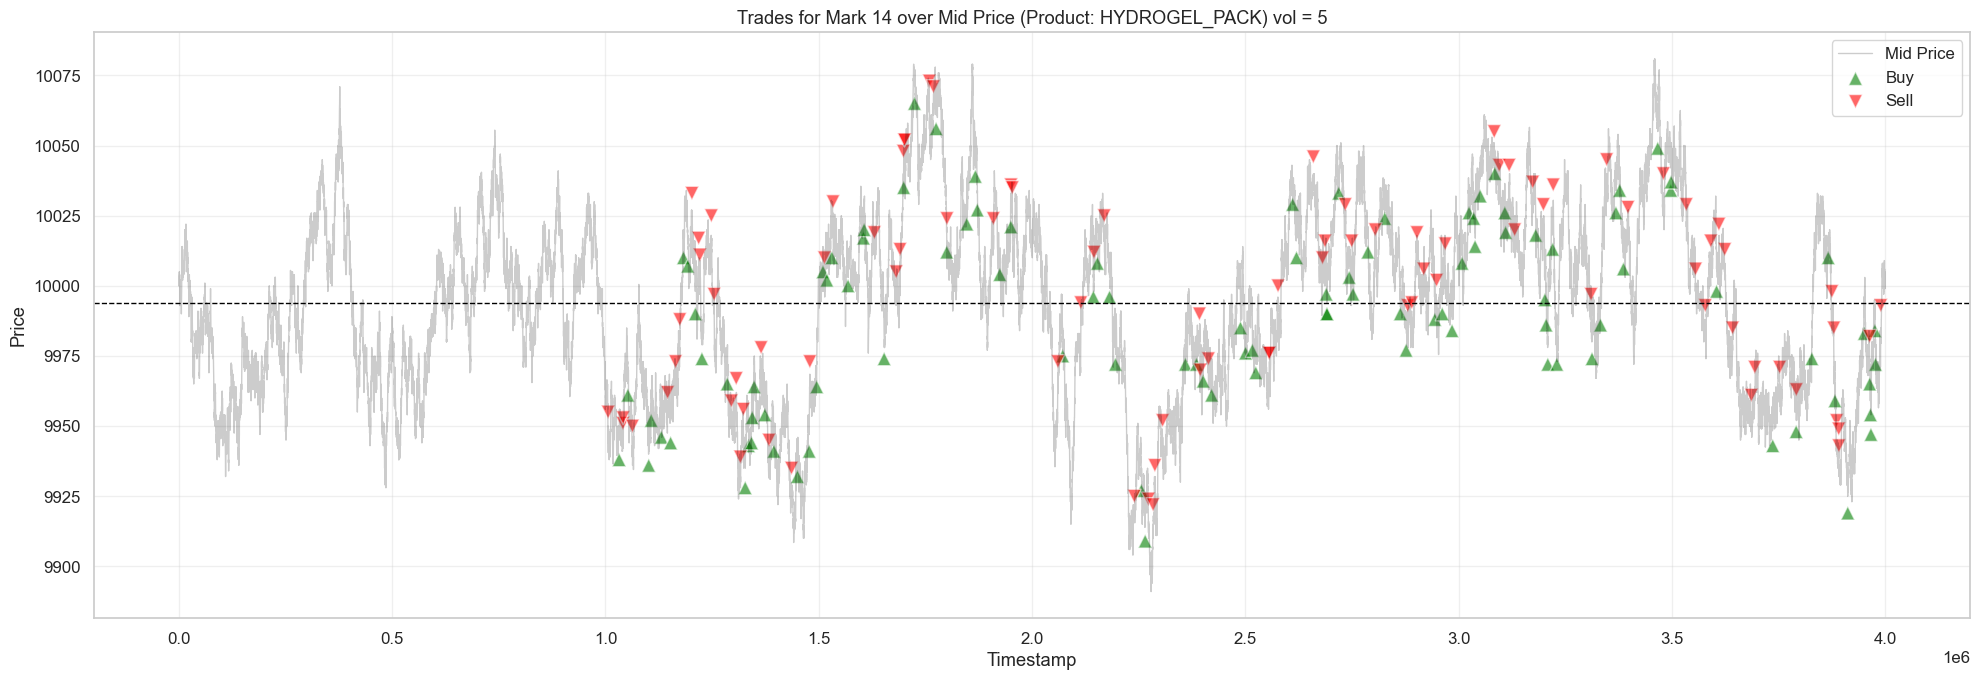

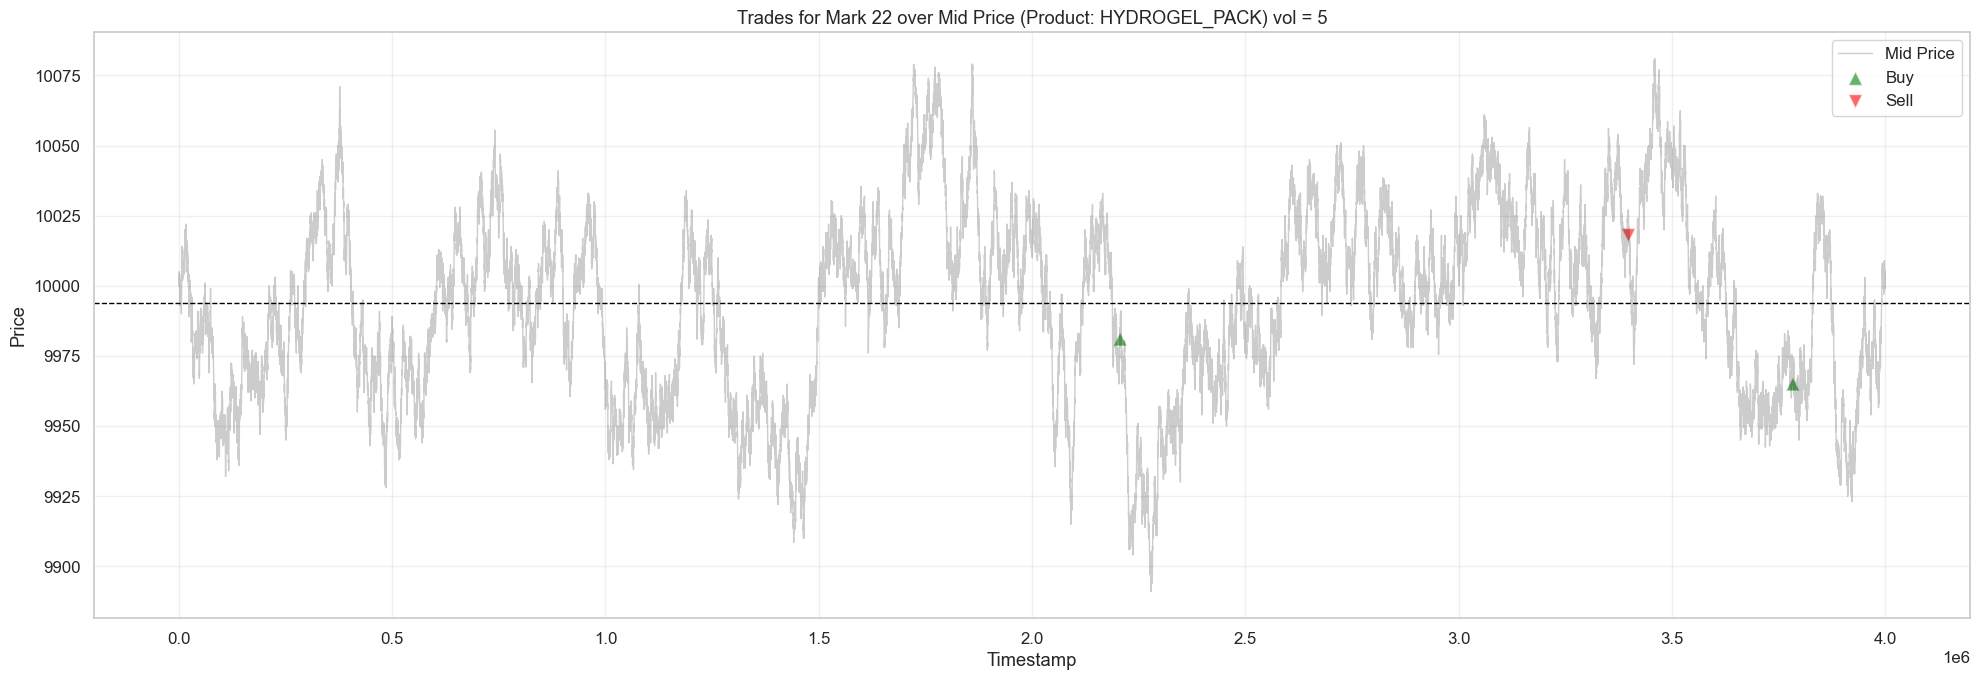

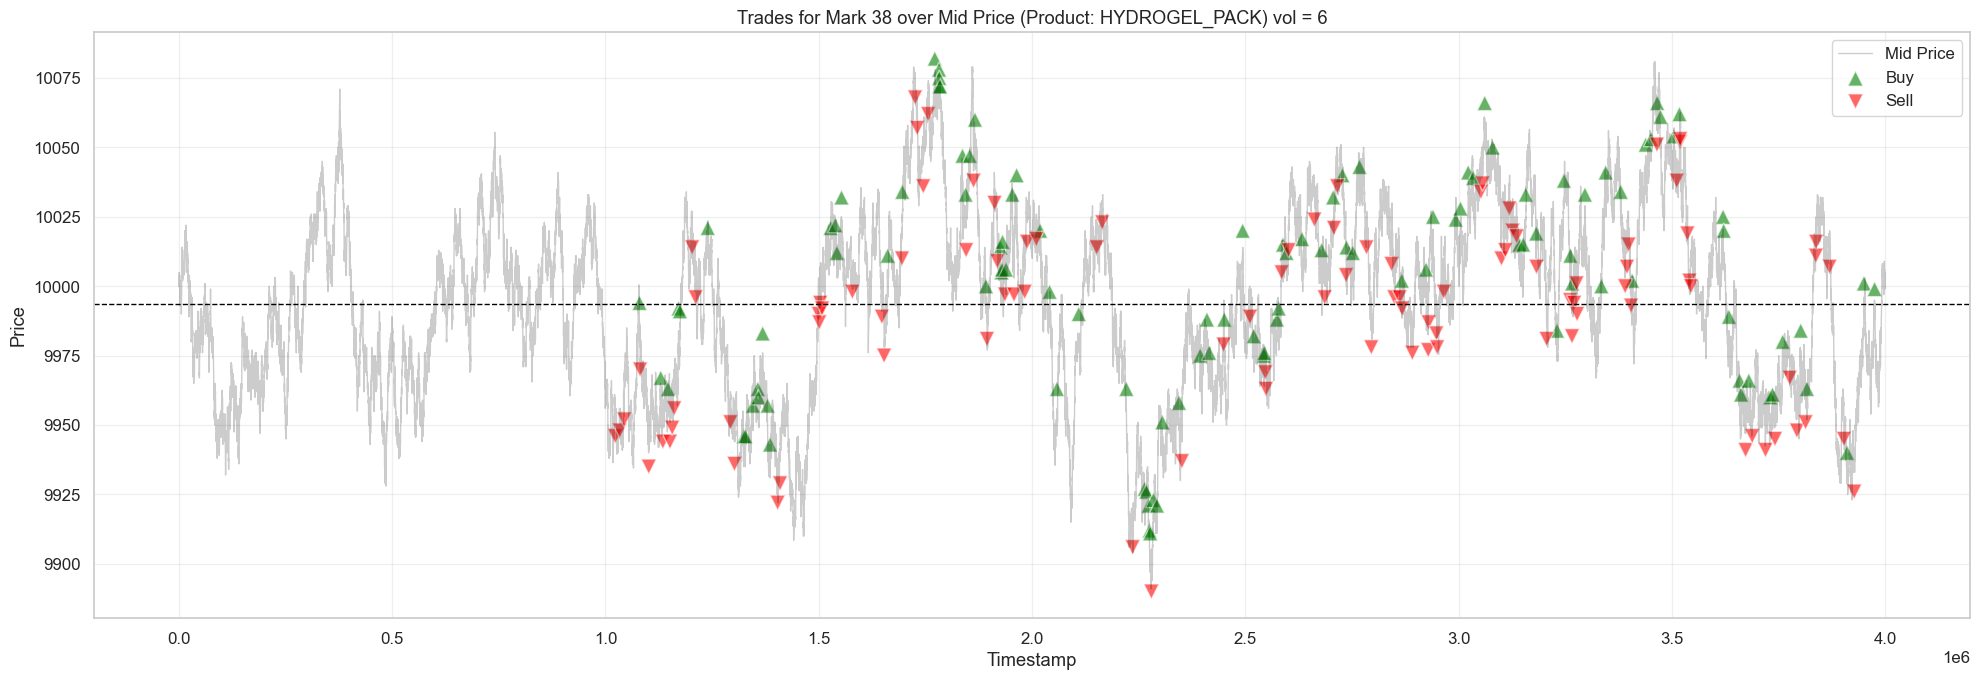

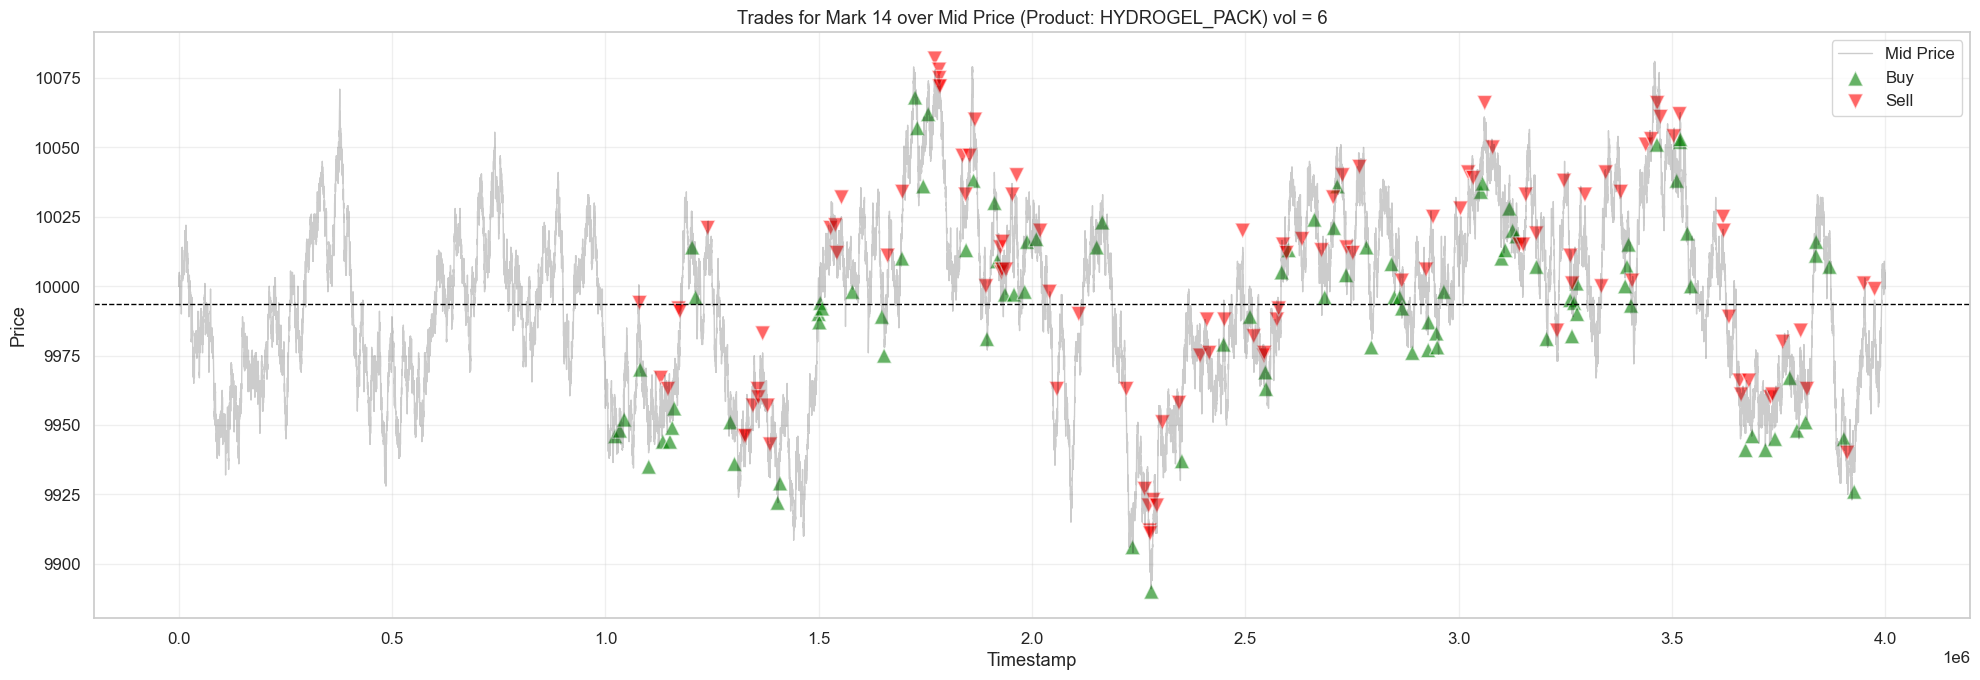

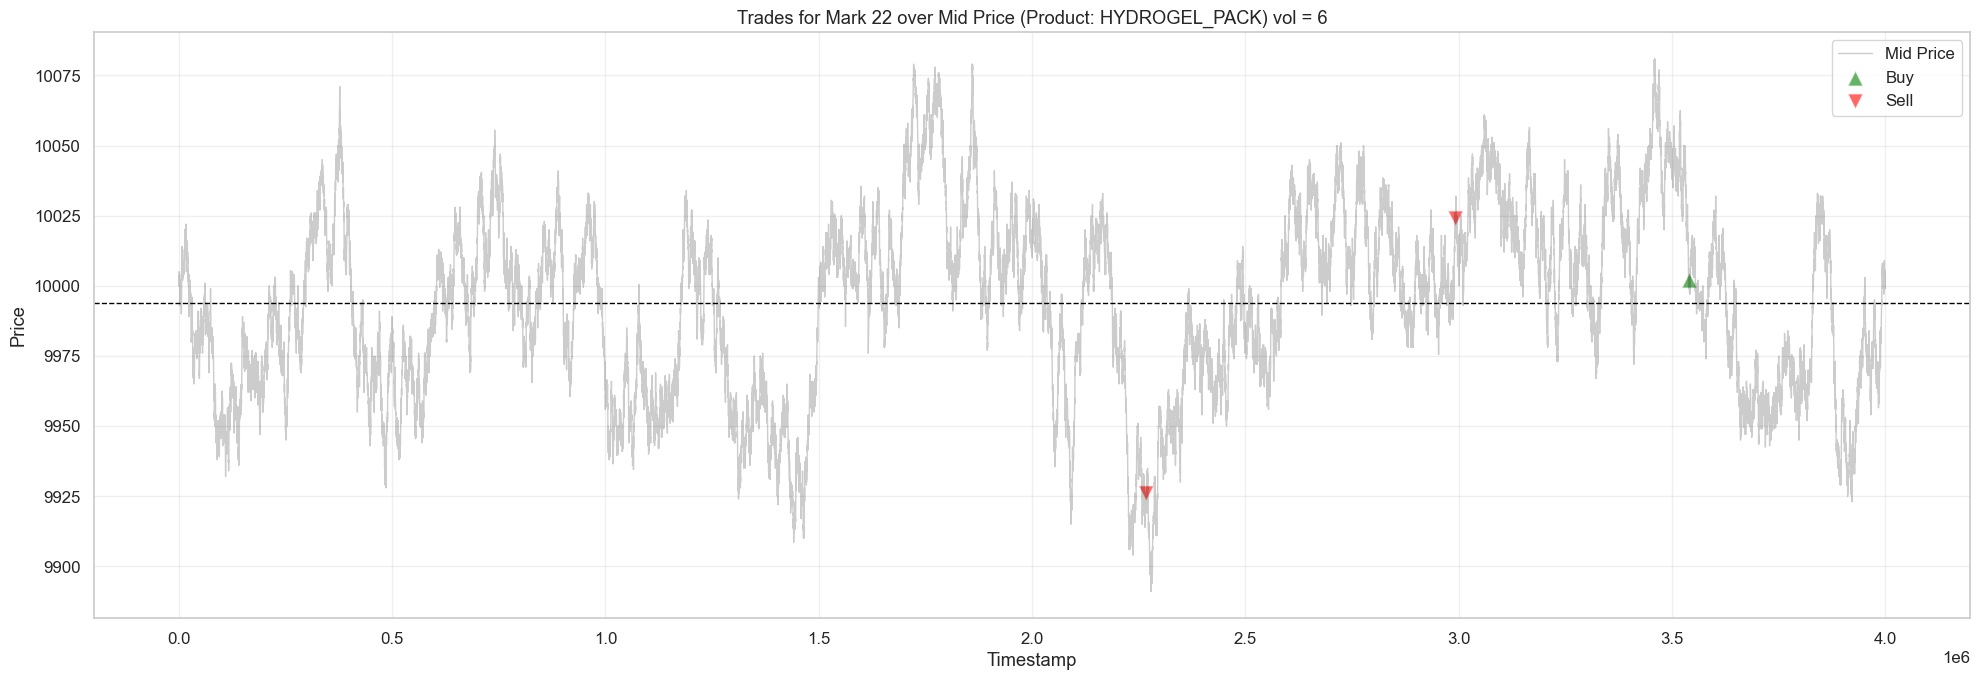

In [7]:
# 2. Identify all unique traders (ignoring empty strings/NaNs)
all_traders = pd.concat([df_trades['buyer'], df_trades['seller']]).dropna().unique()
traders = [t for t in all_traders if str(t).strip() != '']
MIN_SIZE = 2
MAX_SIZE = 6

#df_trades_large = df_trades[df_trades['quantity'] >= MIN_SIZE]
# df_trades_large = df_trades[df_trades['quantity'] <= MAX_SIZE]

if not traders:
    print("No named traders found in the buyer/seller columns.")
else:
    for i in range(MIN_SIZE, MAX_SIZE + 1):
        for trader in traders:
            df_trades_large = df_trades[df_trades['quantity'] == i]
            plt.figure(figsize=(20, 7))
            plt.axhline(df_prices['mid_price'].mean(), color='black', linestyle='--', linewidth = 1)
            
            # Plot the Mid Price as a baseline
            plt.plot(df_prices['timestamp'], df_prices['mid_price'], 
                    label='Mid Price', color='black', alpha=0.2, linewidth=1)
            
            # Filter trades where the trader is the BUYER (Green)
            buys = df_trades_large[df_trades_large['buyer'] == trader]
            if not buys.empty:
                plt.scatter(buys['timestamp'], buys['price'], 
                            s=buys['quantity'] * 20,  # Scale size by volume
                            c='green', label='Buy', alpha=0.6, edgecolors='white', marker='^')
            
            # Filter trades where the trader is the SELLER (Red)
            sells = df_trades_large[df_trades_large['seller'] == trader]
            if not sells.empty:
                plt.scatter(sells['timestamp'], sells['price'], 
                            s=sells['quantity'] * 20,  # Scale size by volume
                            c='red', label='Sell', alpha=0.6, edgecolors='white', marker='v')
            
            plt.title(f"Trades for {trader} over Mid Price (Product: HYDROGEL_PACK) vol = {i}")
            plt.xlabel("Timestamp")
            plt.ylabel("Price")
            plt.legend(loc='upper right')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()


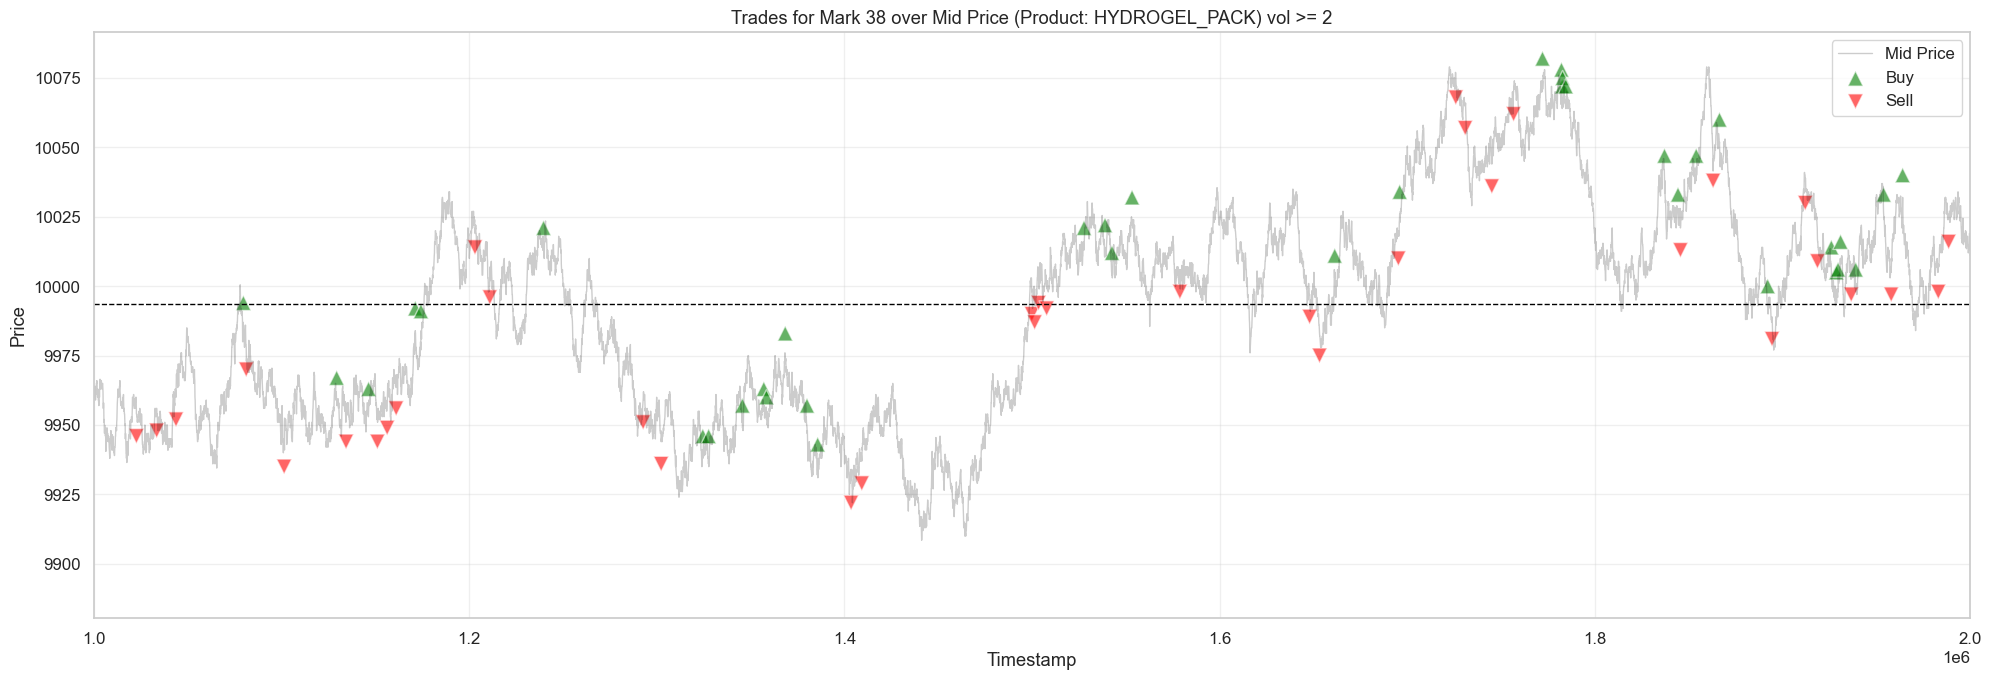

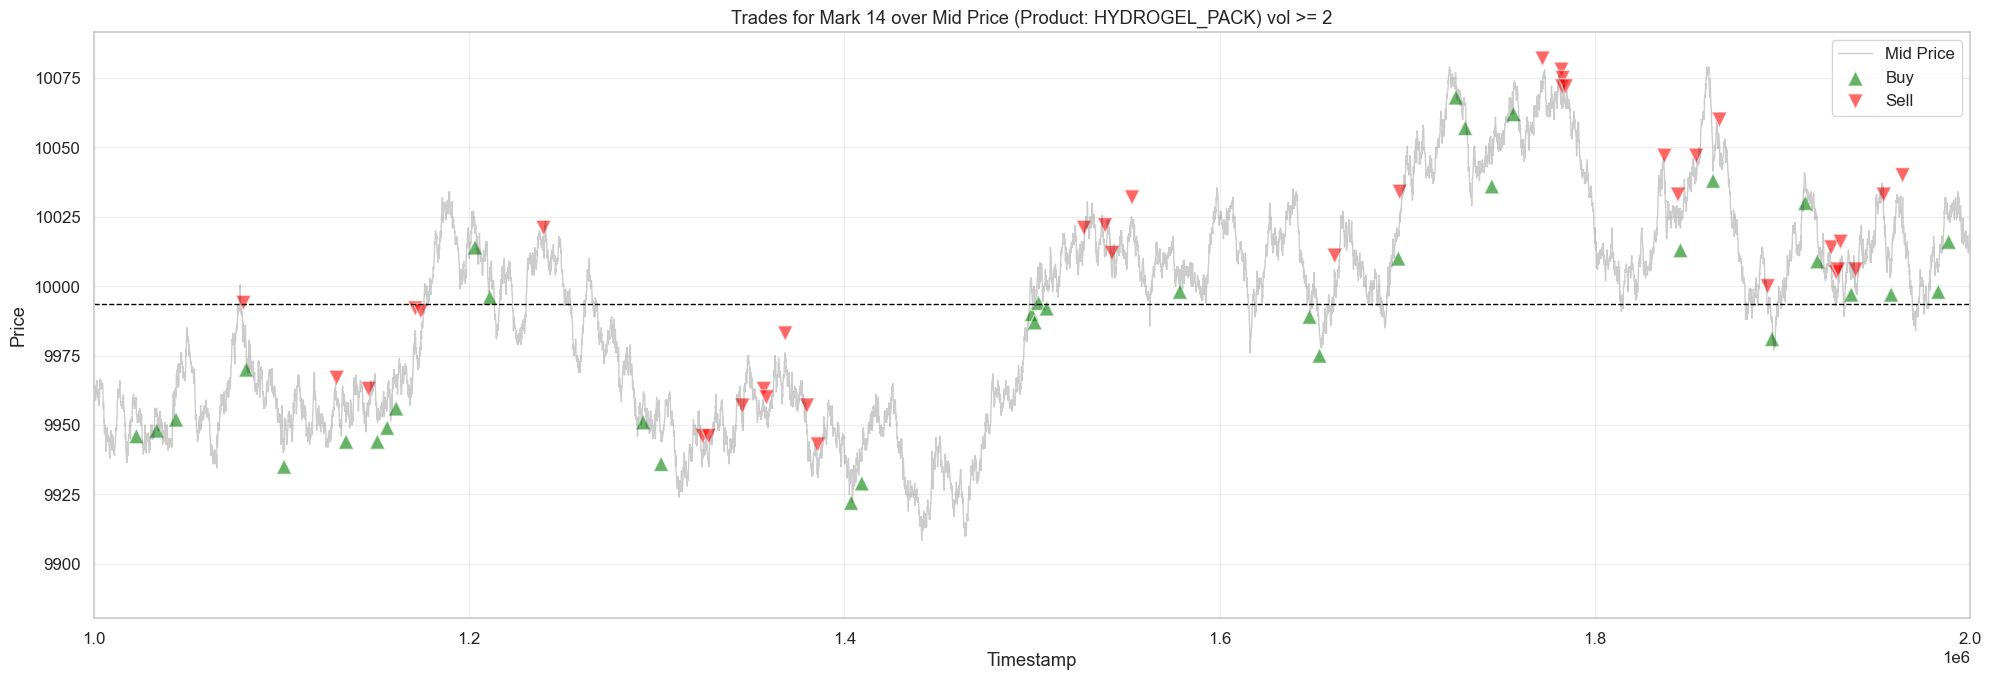

In [8]:
size = 2
traders = ['Mark 38', 'Mark 14']

#df_trades_large = df_trades[df_trades['quantity'] >= MIN_SIZE]
# df_trades_large = df_trades[df_trades['quantity'] <= MAX_SIZE]

if not traders:
    print("No named traders found in the buyer/seller columns.")
else:
    for trader in traders:
        df_trades_large = df_trades[df_trades['quantity'] == i]
        plt.figure(figsize=(20, 7))
        plt.axhline(df_prices['mid_price'].mean(), color='black', linestyle='--', linewidth = 1)
        
        # Plot the Mid Price as a baseline
        plt.plot(df_prices['timestamp'], df_prices['mid_price'], 
                label='Mid Price', color='black', alpha=0.2, linewidth=1)
        
        # Filter trades where the trader is the BUYER (Green)
        buys = df_trades_large[df_trades_large['buyer'] == trader]
        if not buys.empty:
            plt.scatter(buys['timestamp'], buys['price'], 
                        s=buys['quantity'] * 20,  # Scale size by volume
                        c='green', label='Buy', alpha=0.6, edgecolors='white', marker='^')
        
        # Filter trades where the trader is the SELLER (Red)
        sells = df_trades_large[df_trades_large['seller'] == trader]
        if not sells.empty:
            plt.scatter(sells['timestamp'], sells['price'], 
                        s=sells['quantity'] * 20,  # Scale size by volume
                        c='red', label='Sell', alpha=0.6, edgecolors='white', marker='v')
        
        plt.title(f"Trades for {trader} over Mid Price (Product: HYDROGEL_PACK) vol >= {MIN_SIZE}")
        plt.xlabel("Timestamp")
        plt.ylabel("Price")
        plt.legend(loc='upper right')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.xlim(1_000_000, 2_000_000)
        plt.show()


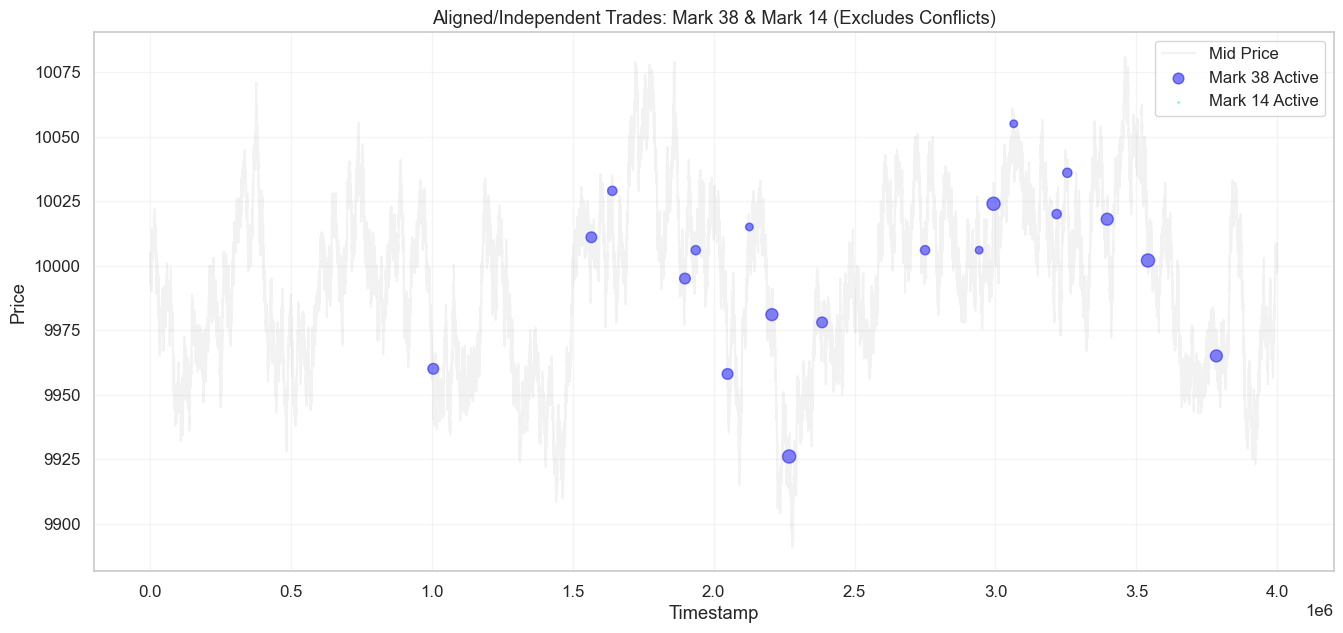

Found 19 aligned timestamps.


In [9]:
# --- Configuration ---
trader_a = 'Mark 38'
trader_b = 'Mark 14'
# ---------------------

# 1. Identify timestamps per direction for each trader
a_buys_ts = set(df_trades[df_trades['buyer'] == trader_a]['timestamp'])
a_sells_ts = set(df_trades[df_trades['seller'] == trader_a]['timestamp'])

b_buys_ts = set(df_trades[df_trades['buyer'] == trader_b]['timestamp'])
b_sells_ts = set(df_trades[df_trades['seller'] == trader_b]['timestamp'])

# 2. Identify "CONFLICT" timestamps (where one buys and the other sells)
conflict_1 = a_buys_ts.intersection(b_sells_ts) # A buys, B sells
conflict_2 = a_sells_ts.intersection(b_buys_ts) # A sells, B buys
all_conflicts = conflict_1.union(conflict_2)

# 3. Identify timestamps where either is active
all_active_ts = a_buys_ts | a_sells_ts | b_buys_ts | b_sells_ts

# 4. Filter for Aligned/Non-Conflicting timestamps
aligned_ts = all_active_ts - all_conflicts

if not aligned_ts:
    print("No non-conflicting trade timestamps found.")
else:
    # Filter trades for plotting
    df_aligned_trades = df_trades[df_trades['timestamp'].isin(aligned_ts)]
    
    plt.figure(figsize=(16, 7))
    
    # Background Mid Price
    plt.plot(df_prices['timestamp'], df_prices['mid_price'], 
             color='grey', alpha=0.1, label='Mid Price')
    
    # Plot Mark 38 trades (Blue)
    a_trades = df_aligned_trades[(df_aligned_trades['buyer'] == trader_a) | (df_aligned_trades['seller'] == trader_a)]
    plt.scatter(a_trades['timestamp'], a_trades['price'], 
                s=a_trades['quantity']*15, c='blue', alpha=0.5, label=f'{trader_a} Active')
    
    # Plot Mark 14 trades (Cyan)
    b_trades = df_aligned_trades[(df_aligned_trades['buyer'] == trader_b) | (df_aligned_trades['seller'] == trader_b)]
    plt.scatter(b_trades['timestamp'], b_trades['price'], 
                s=b_trades['quantity']*15, c='cyan', alpha=0.5, label=f'{trader_b} Active')
    
    plt.title(f"Aligned/Independent Trades: {trader_a} & {trader_b} (Excludes Conflicts)")
    plt.xlabel("Timestamp")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

    print(f"Found {len(aligned_ts)} aligned timestamps.")

[(2, 2), (2, 3), (3, 2), (3, 3)]


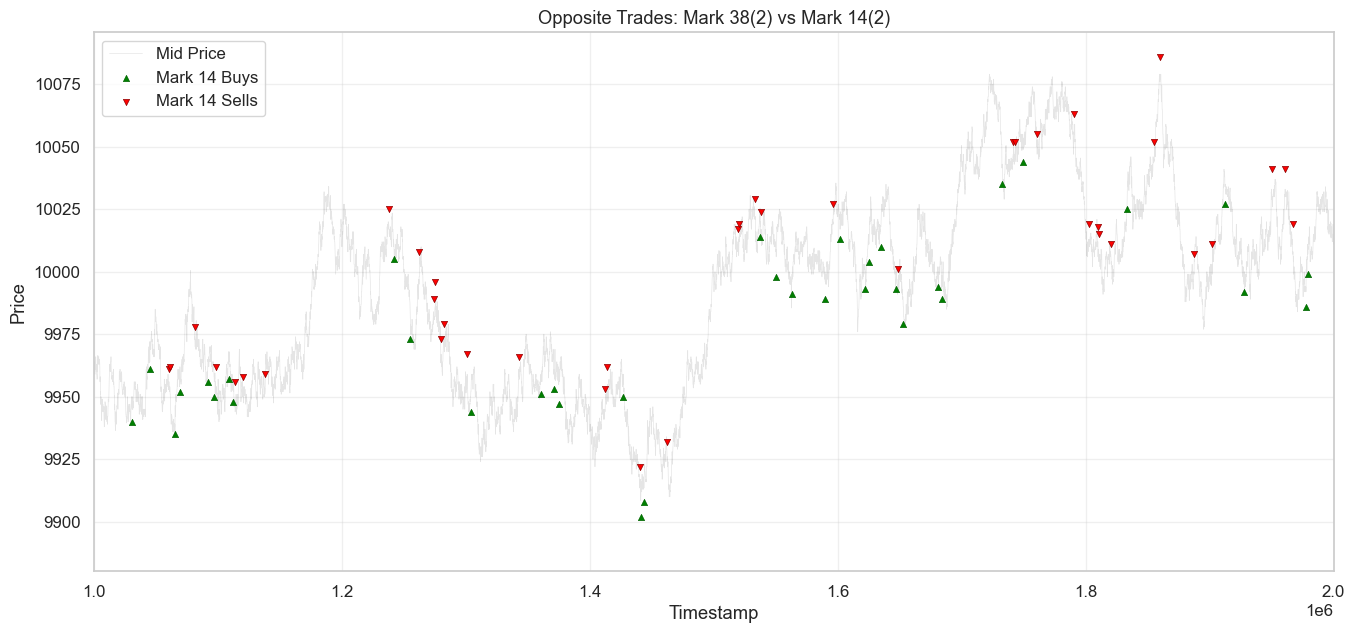

Found 199 timestamps where they trade opposite to each other.
No opposite trades found matching Mark 38:2 and Mark 14:3
No opposite trades found matching Mark 38:3 and Mark 14:2


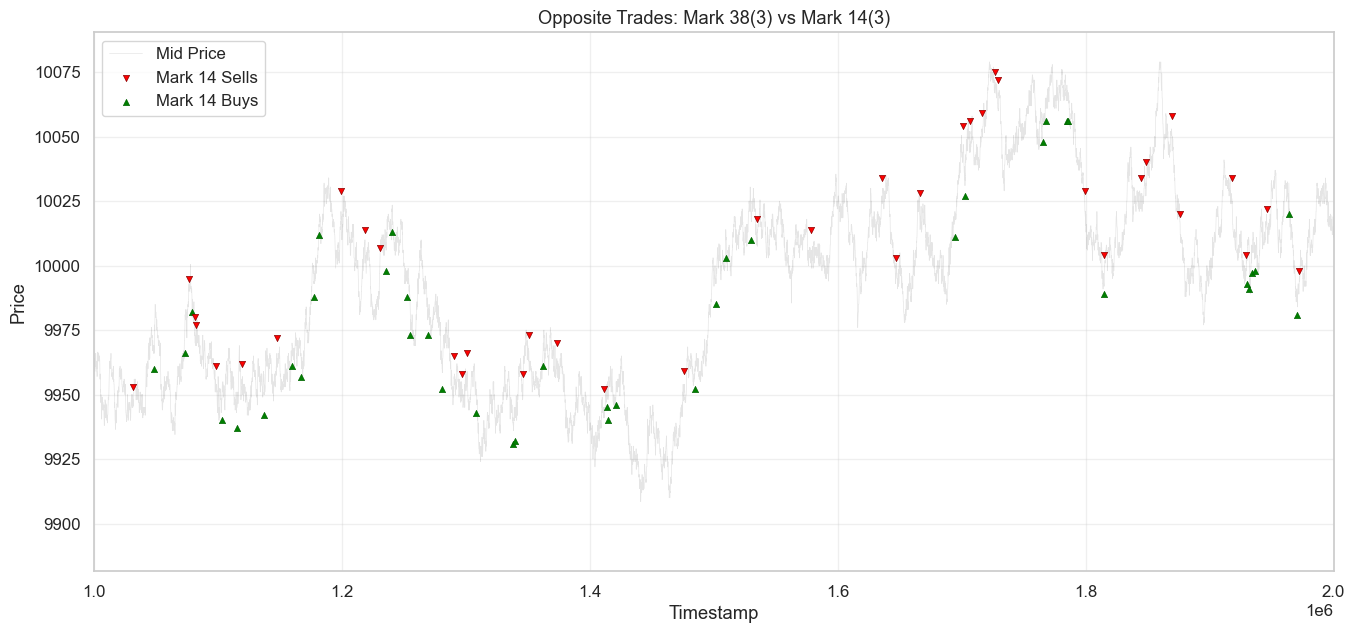

Found 206 timestamps where they trade opposite to each other.


In [ ]:
from seaborn._core.properties import LineWidth
import matplotlib.pyplot as plt
from itertools import product

# --- Configuration ---
trader_a = 'Mark 38'
size_a = 3        # Exact quantity for Trader A

trader_b = 'Mark 14'
size_b = 3       # Exact quantity for Trader B
# ---------------------

val = list(range(2, 4))
val = list(product(val, val))
print(val)
for size_a, size_b in val:
    # 1. Filter for A's exact matches
    buys_a = df_trades[(df_trades['buyer'] == trader_a) & (df_trades['quantity'] == size_a)]
    sells_a = df_trades[(df_trades['seller'] == trader_a) & (df_trades['quantity'] == size_a)]

    # 2. Filter for B's exact matches
    buys_b = df_trades[(df_trades['buyer'] == trader_b) & (df_trades['quantity'] == size_b)]
    sells_b = df_trades[(df_trades['seller'] == trader_b) & (df_trades['quantity'] == size_b)]

    # 3. Find timestamps where they are "Opposite"
    # Condition 1: A buys, B sells (Mark 14 is SELLING)
    opp_1_times = set(buys_a['timestamp']).intersection(set(sells_b['timestamp']))

    # Condition 2: B buys, A sells (Mark 14 is BUYING)
    opp_2_times = set(buys_b['timestamp']).intersection(set(sells_a['timestamp']))

    # Combine all overlapping timestamps
    all_opp_times = opp_1_times.union(opp_2_times)

    if not all_opp_times:
        print(f"No opposite trades found matching {trader_a}:{size_a} and {trader_b}:{size_b}")
    else:
        # Filter trades to plot
        df_plot = df_trades[df_trades['timestamp'].isin(all_opp_times)]
        
        plt.figure(figsize=(16, 7))
        plt.plot(df_prices['timestamp'], df_prices['mid_price'], color='black', alpha=0.1, label='Mid Price', linewidth=0.5)

        # Tracking labels for legend
        has_buy_label = False
        has_sell_label = False

        # Iterate through timestamps to plot the specific markers
        for ts in sorted(list(all_opp_times)):
            ts_trades = df_plot[df_plot['timestamp'] == ts]
            price = ts_trades['price'].mean()
            
            # Mark 14 Sells (Red Down Arrow)
            if ts in opp_1_times:
                label = f"{trader_b} Sells" if not has_sell_label else ""
                plt.scatter(ts, price, marker='v', color='red', s=20, label=label, edgecolors='darkred', linewidths=0.5, zorder=3)
                has_sell_label = True
            
            # Mark 14 Buys (Green Up Arrow)
            if ts in opp_2_times:
                label = f"{trader_b} Buys" if not has_buy_label else ""
                plt.scatter(ts, price, marker='^', color='green', s=20, label=label, edgecolors='darkgreen', linewidths=0.5, zorder=3)
                has_buy_label = True
            
        plt.title(f"Opposite Trades: {trader_a}({size_a}) vs {trader_b}({size_b})")
        plt.xlabel("Timestamp")
        plt.ylabel("Price")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.xlim(1_000_000, 2_000_000)
        plt.show()

        print(f"Found {len(all_opp_times)} timestamps where they trade opposite to each other.")


[(2, 2), (2, 3), (3, 2), (3, 3)]
No opposite trades found matching Mark 38:2 and Mark 14:3
No opposite trades found matching Mark 38:3 and Mark 14:2


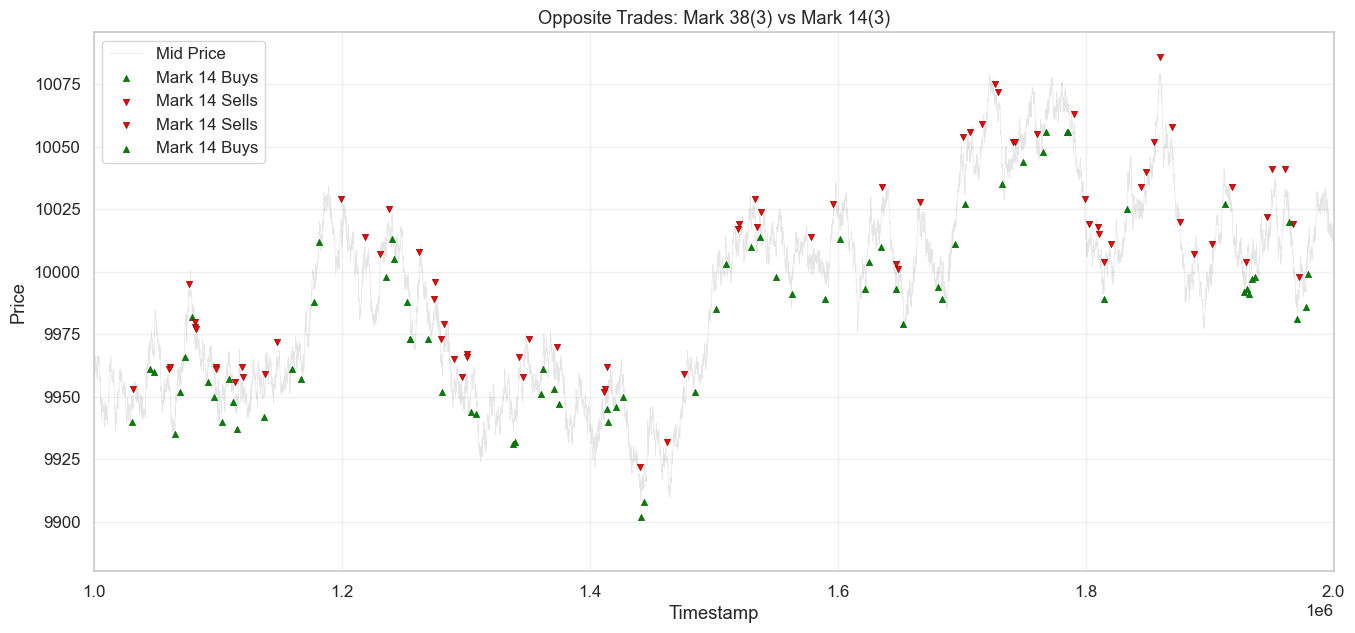

In [15]:
from seaborn._core.properties import LineWidth
import matplotlib.pyplot as plt
from itertools import product

# --- Configuration ---
trader_a = 'Mark 38'
size_a = 3        # Exact quantity for Trader A

trader_b = 'Mark 14'
size_b = 3       # Exact quantity for Trader B
# ---------------------

plt.figure(figsize=(16, 7))
plt.plot(df_prices['timestamp'], df_prices['mid_price'], color='black', alpha=0.1, label='Mid Price', linewidth=0.5)

val = list(range(2, 4))
val = list(product(val, val))
print(val)
for size_a, size_b in val:
    # 1. Filter for A's exact matches
    buys_a = df_trades[(df_trades['buyer'] == trader_a) & (df_trades['quantity'] == size_a)]
    sells_a = df_trades[(df_trades['seller'] == trader_a) & (df_trades['quantity'] == size_a)]

    # 2. Filter for B's exact matches
    buys_b = df_trades[(df_trades['buyer'] == trader_b) & (df_trades['quantity'] == size_b)]
    sells_b = df_trades[(df_trades['seller'] == trader_b) & (df_trades['quantity'] == size_b)]

    # 3. Find timestamps where they are "Opposite"
    # Condition 1: A buys, B sells (Mark 14 is SELLING)
    opp_1_times = set(buys_a['timestamp']).intersection(set(sells_b['timestamp']))

    # Condition 2: B buys, A sells (Mark 14 is BUYING)
    opp_2_times = set(buys_b['timestamp']).intersection(set(sells_a['timestamp']))

    # Combine all overlapping timestamps
    all_opp_times = opp_1_times.union(opp_2_times)

    if not all_opp_times:
        print(f"No opposite trades found matching {trader_a}:{size_a} and {trader_b}:{size_b}")
    else:
        # Filter trades to plot
        df_plot = df_trades[df_trades['timestamp'].isin(all_opp_times)]

        # Tracking labels for legend
        has_buy_label = False
        has_sell_label = False

        # Iterate through timestamps to plot the specific markers
        for ts in sorted(list(all_opp_times)):
            ts_trades = df_plot[df_plot['timestamp'] == ts]
            price = ts_trades['price'].mean()
            
            # Mark 14 Sells (Red Down Arrow)
            if ts in opp_1_times:
                label = f"{trader_b} Sells" if not has_sell_label else ""
                plt.scatter(ts, price, marker='v', color='red', s=20, label=label, edgecolors='darkred', linewidths=0.5, zorder=3)
                has_sell_label = True
            
            # Mark 14 Buys (Green Up Arrow)
            if ts in opp_2_times:
                label = f"{trader_b} Buys" if not has_buy_label else ""
                plt.scatter(ts, price, marker='^', color='green', s=20, label=label, edgecolors='darkgreen', linewidths=0.5, zorder=3)
                has_buy_label = True

plt.title(f"Opposite Trades: {trader_a}({size_a}) vs {trader_b}({size_b})")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(1_000_000, 2_000_000)
plt.show()


[2, 3, 4, 5, 6]


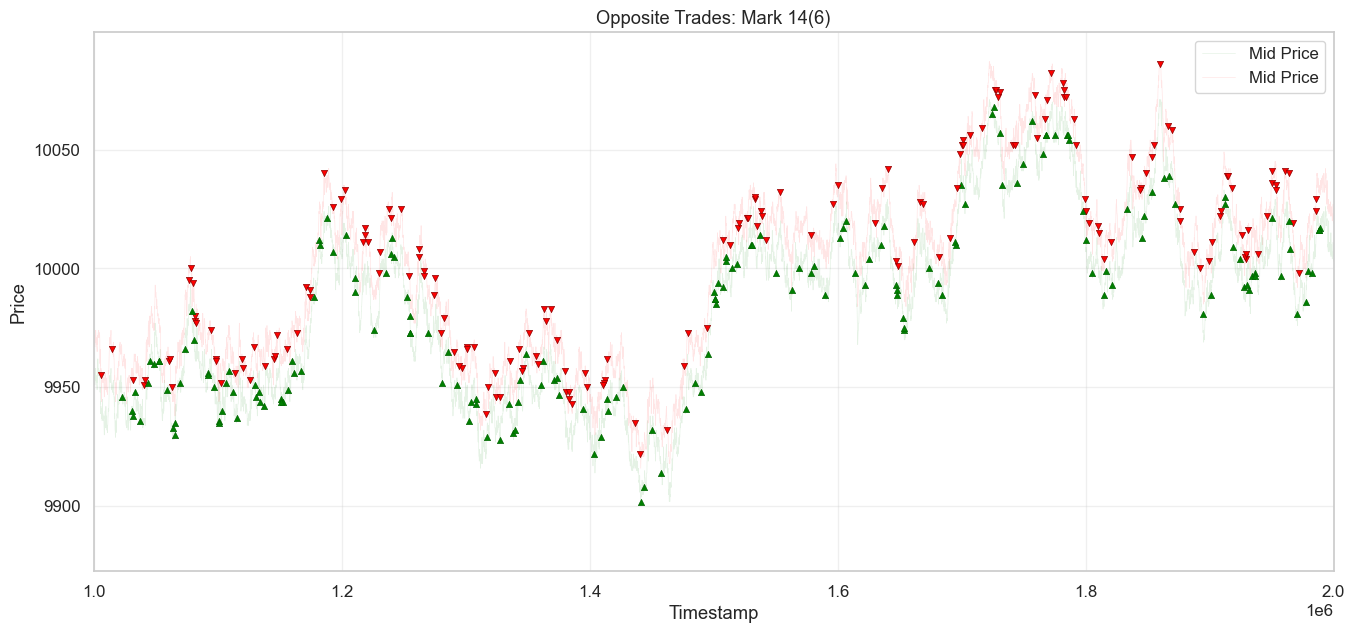

In [21]:
from seaborn._core.properties import LineWidth
import matplotlib.pyplot as plt
from itertools import product

trader = 'Mark 14'
val = list(range(2, 7))

plt.figure(figsize=(16, 7))
# plt.plot(df_prices['timestamp'], df_prices['mid_price'], color='black', alpha=0.1, label='Mid Price', linewidth=0.5)
plt.plot(df_prices['timestamp'], df_prices['bid_price_1'], color='green', alpha=0.1, label='Mid Price', linewidth=0.5)
plt.plot(df_prices['timestamp'], df_prices['ask_price_1'], color='red', alpha=0.1, label='Mid Price', linewidth=0.5)

print(val)
for size in val:
    # 1. Filter for A's exact matches
    buys = df_trades[(df_trades['buyer'] == trader) & (df_trades['quantity'] == size)]
    sells = df_trades[(df_trades['seller'] == trader) & (df_trades['quantity'] == size)]

    label = f"{trader_b} Sells" if not has_sell_label else ""
    plt.scatter(sells['timestamp'], sells['price'], marker='v', color='red', s=20, label=label, edgecolors='darkred', linewidths=0.5, zorder=3)

    label = f"{trader_b} Buys" if not has_buy_label else ""
    plt.scatter(buys['timestamp'], buys['price'], marker='^', color='green', s=20, label=label, edgecolors='darkgreen', linewidths=0.5, zorder=3)

plt.title(f"Opposite Trades: {trader}({size})")
plt.xlabel("Timestamp")
plt.ylabel("Price")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(1_000_000, 2_000_000)
plt.show()
